# Controversy Axes in UK Parliamentary Debates: an LLM-driven approach


## Abstract
The increasing volume of political information, combined with the spread of 
misinformation, makes it difficult for citizens to track and interpret 
parliamentary debate. This work presents an NLP pipeline for automatic stance 
detection and controversy analysis applied to real UK parliamentary data 
(ParlEE Plenary Speeches V2 dataset [1], 2009–2019).

The proposed methodology consists of the following steps:
1. Topic selection and speech filtering by keyword and policy area
2. Opinion sentence detection via a fine-tuned classification model
3. Per-politician stance summarization using a local LLM
4. Issue identification and anchor generation along controversy axes
5. Embedding-based projection of party stances onto axes of controversy
6. Visualization of party positions on each axis

The approach is inspired by the KOKKAI DOC framework [2] and is evaluated 
on topics including the Israeli-Palestinian conflict, climate change and nuclear energy.

## The notebook

In [57]:
import pandas as pd
import sys
sys.path.append("./../src")
from setfit import SetFitModel
from rouge_score import rouge_scorer
import json
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from datasets import load_dataset
from StanceDetector import StanceDetector
import utils

random_seed=41


## Dataset

For this work we use a reduced version of the ParlEE Plenary Speeches V2 
dataset [1], available on HuggingFace as `andreacristiano/uk_parliament`. 
The dataset contains UK parliamentary debates spanning from 2009 to 2019, 
where each entry represents a single speech by a Member of Parliament (MP).

The dataset contains the following columns:

| Column | Description |
|---|---|
| `date` | Date of the parliamentary session |
| `agenda` | Brief description of the discussion topic |
| `speaker` | Full name of the MP |
| `party` | Party acronym (e.g. `Lab`, `Con`, `LD`) |
| `text` | Text of the intervention |
| `policyarea` | Numeric code identifying the policy area |
| `year` | Year of the discussion |

In [63]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

Loading ```records.json```. This file contains keyword and policy area codes that will be later used to filter the speeches in the dataset.

In [39]:
# read records from json file
with open('./../data/external/records.json', 'r') as f:
    records = json.load(f) 


In [5]:
# FOR DEBUGGING PURPOSES, TO RELOAD THE MODULE WITHOUT RESTARTING THE KERNEL

import importlib
import StanceDetector as sd_module

def reload_detector():
    importlib.reload(sd_module)
    return sd_module.StanceDetector

In [ ]:

# DEBUG----------
StanceDetector = reload_detector()
# ------------------
uk=StanceDetector(df1, records, random_seed=random_seed)

c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Gaza

The first topic we are going to analyze is 'Gaza'. We are going to consider all the debates revolving around the Israeli-Palestinian conflict.

In [7]:
topic='Gaza'
years = [2011, 2012, 2013, 2014]

### First part of the pipeline
1. Filtering speeches by keyword and policy area
2. Detecting opinion-based speeches
3. Summarizing the stance of each politician

In [ ]:

filtered_df= uk.filter_speeches(topic, years=years) 
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [8]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)

### Topics and Axes of Controversy

For each topic of interest, we define a pair of **stance anchors** — short 
textual descriptions representing the two opposing poles of the debate 
(labeled `PRO` and `CON`). These anchors are embedded in the same vector 
space as the speaker summaries, and the axis connecting them defines the 
**axis of controversy** along which each party's position is projected.

We are going to consider a general issue of discussion and respective anchors (```general_anchors```), but also some sub-issues (```anchors```). The 

CONTINUA...

In [14]:
# generated with Claude Sonnet 4.6 (thinking mode)
general_anchors = {
    "topic": "The primary obstacle to peace in the Israeli-Palestinian conflict",
    "pro": (
        "Israeli military actions, settlement expansion, and the blockade of Gaza "
        "are the primary obstacles to a just and lasting peace, causing humanitarian "
        "suffering and undermining the viability of a Palestinian state."
    ),
    "con": (
        "Hamas's terrorism, its rejection of Israel's right to exist, and its use "
        "of violence are the fundamental barriers to any negotiated resolution "
        "and a stable two-state solution."
    )
}


In [33]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: Gaza


In [ ]:
# saving anchors to json file
with open(f'./../data/processed/anchors_{topic}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [10]:
# DEBUG: loading anchors from json file
with open(f'./../data/processed/anchors_{topic}.json', 'r') as f:
    anchors = json.load(f)

In [39]:
anchors

[{'topic': 'The legitimacy of Hamas as a negotiating partner.',
  'pro': 'Hamas’s continued rejection of Israel’s existence, support for violence, and reliance on external actors like Iran fundamentally undermine any possibility of a genuine peace process and necessitate a complete rejection of engagement.',
  'con': 'Hamas’s position is a consequence of the broader conflict and its rejection of engagement is a tactical response to the ongoing situation, requiring a nuanced approach to negotiations.'},
 {'topic': 'The role of Israeli settlements in achieving a two-state solution.',
  'pro': 'The expansion of Israeli settlements directly undermines the feasibility of a two-state solution by encroaching on land designated for a Palestinian state and exacerbating tensions.',
  'con': 'Settlement expansion, while a contentious issue, is a response to legitimate security concerns and does not inherently preclude a negotiated resolution.'},
 {'topic': 'The humanitarian situation in Gaza and 

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.75s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


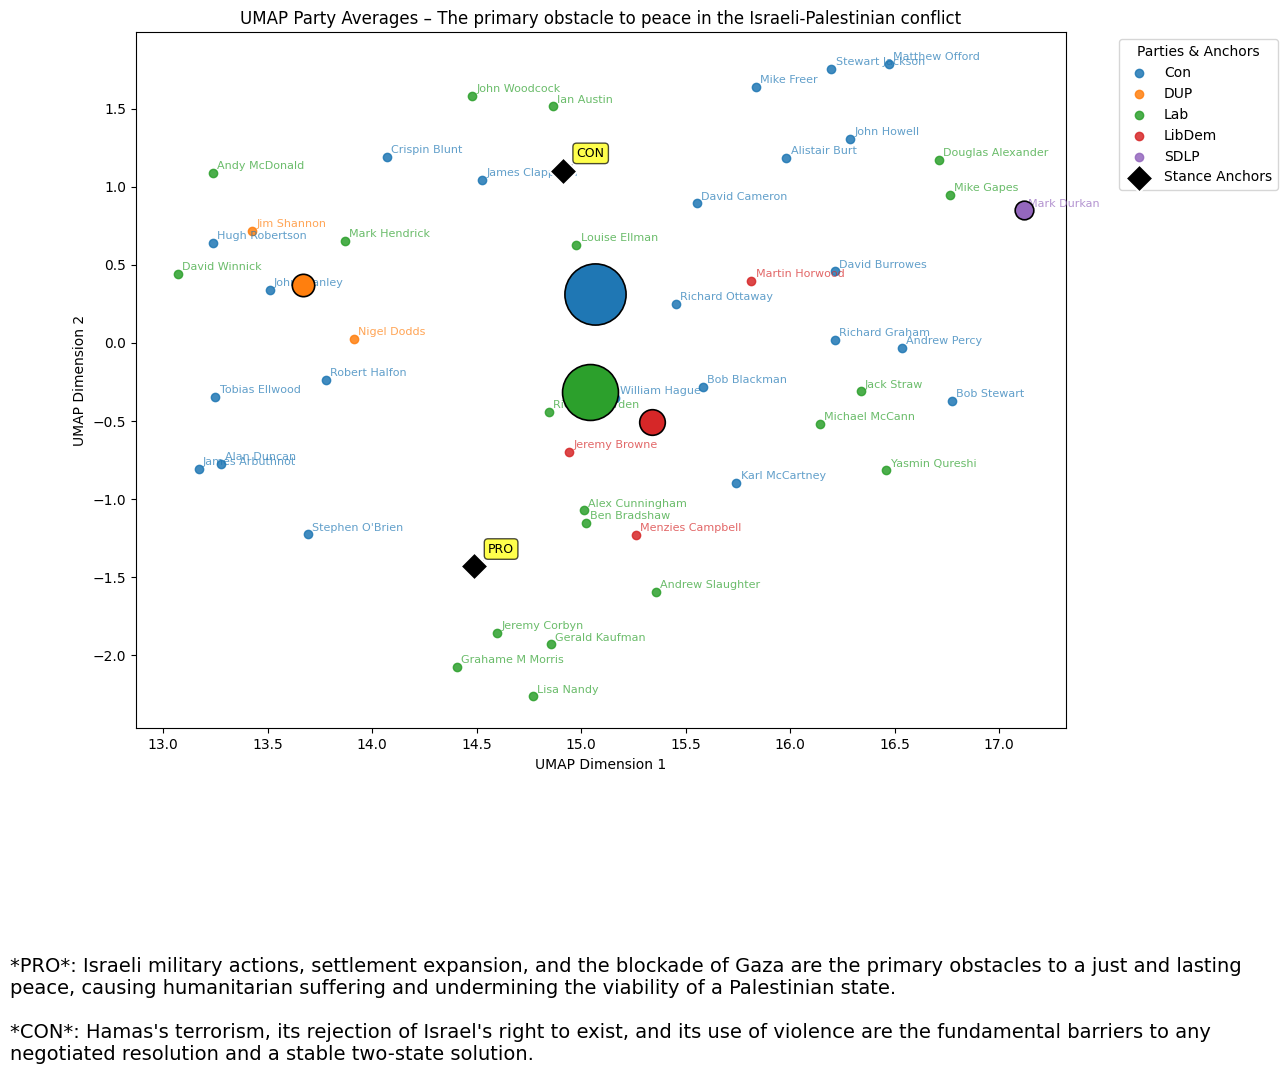

In [15]:
embeddings = uk.compute_umap_embeddings(topic, general_anchors)
uk.plot_umap_party_averages(embeddings, topic)

In [16]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)


# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:05<00:00,  2.75s/it]

Cosine similarity between anchor embeddings:
0.6801569


,party,controversy_score,issue
1,DUP,-0.101363,The primary obstacle to peace in the Israeli-P...
0,Con,-0.090562,The primary obstacle to peace in the Israeli-P...
4,SDLP,-0.072327,The primary obstacle to peace in the Israeli-P...
2,Lab,0.005217,The primary obstacle to peace in the Israeli-P...
3,LibDem,0.023792,The primary obstacle to peace in the Israeli-P...


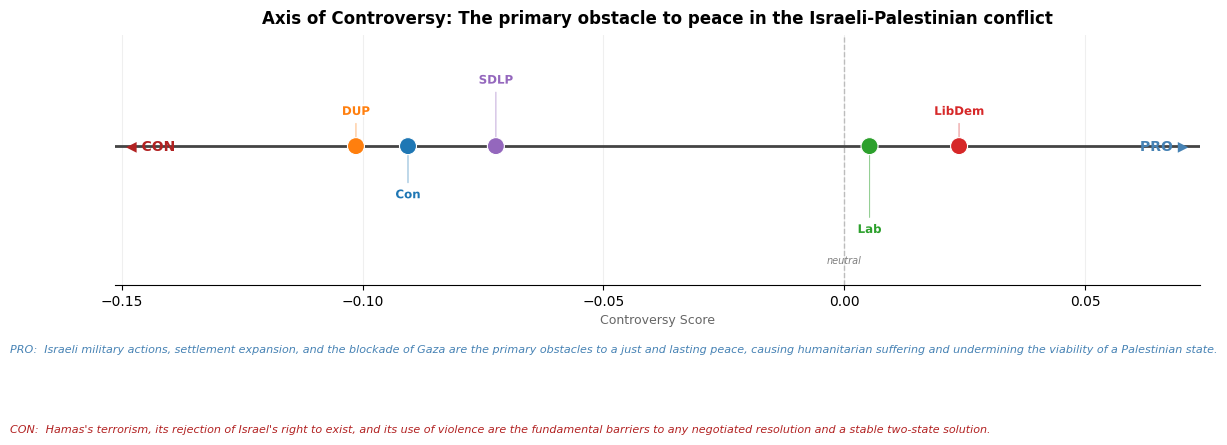

In [17]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.01s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


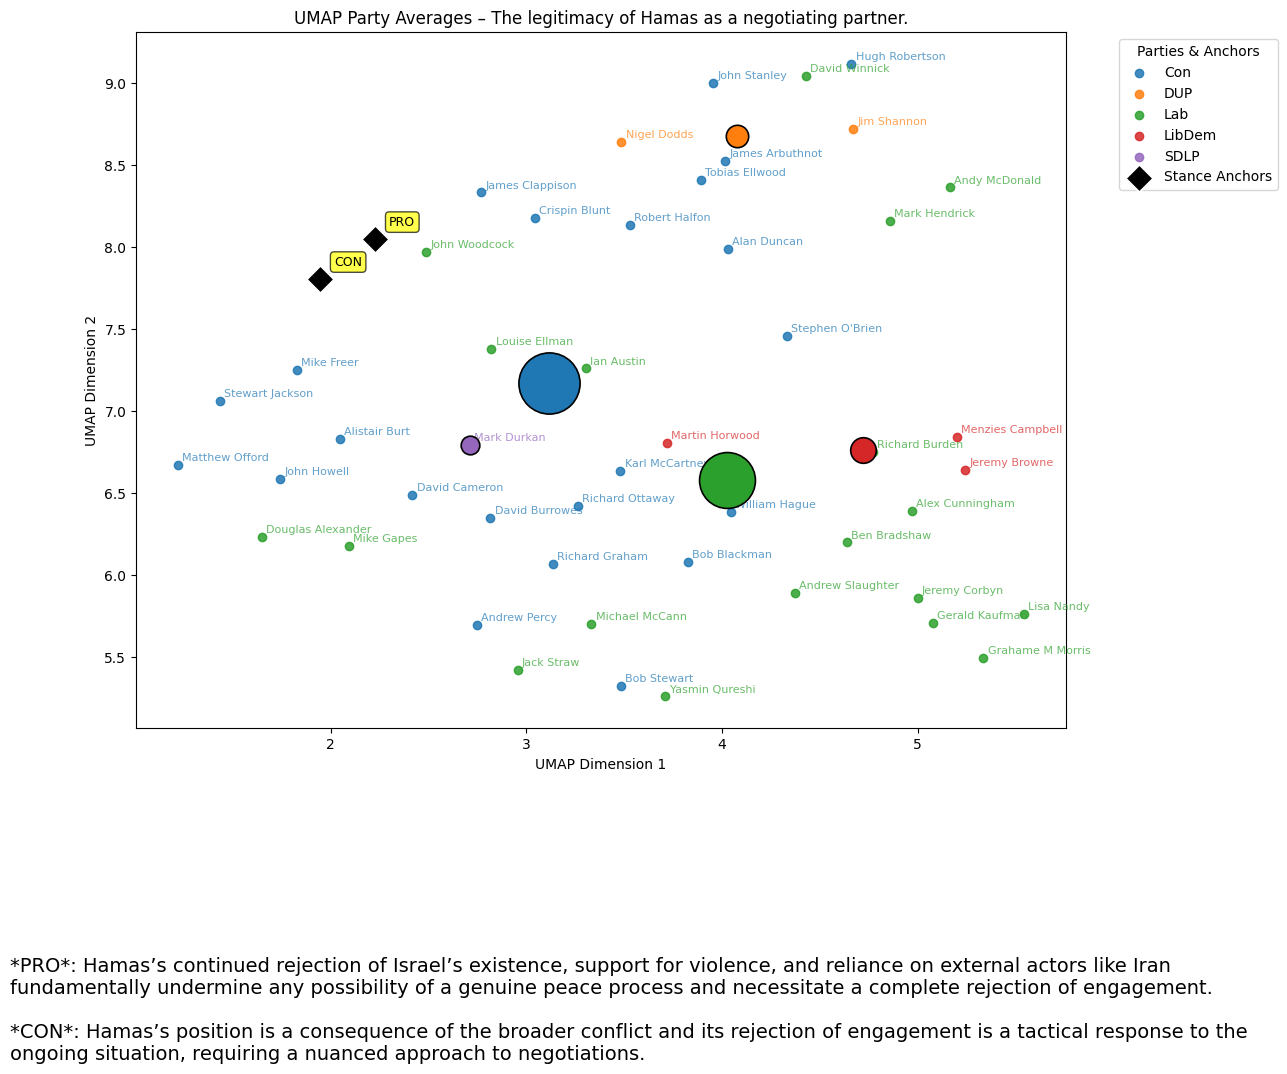

In [11]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [42]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[0])

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = anchors[0]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:14<00:00,  7.13s/it]

Cosine similarity between anchor embeddings:
0.76135385


,party,controversy_score,issue
2,Lab,0.070452,The legitimacy of Hamas as a negotiating partner.
0,Con,0.085167,The legitimacy of Hamas as a negotiating partner.
4,SDLP,0.108534,The legitimacy of Hamas as a negotiating partner.
3,LibDem,0.118766,The legitimacy of Hamas as a negotiating partner.
1,DUP,0.136542,The legitimacy of Hamas as a negotiating partner.


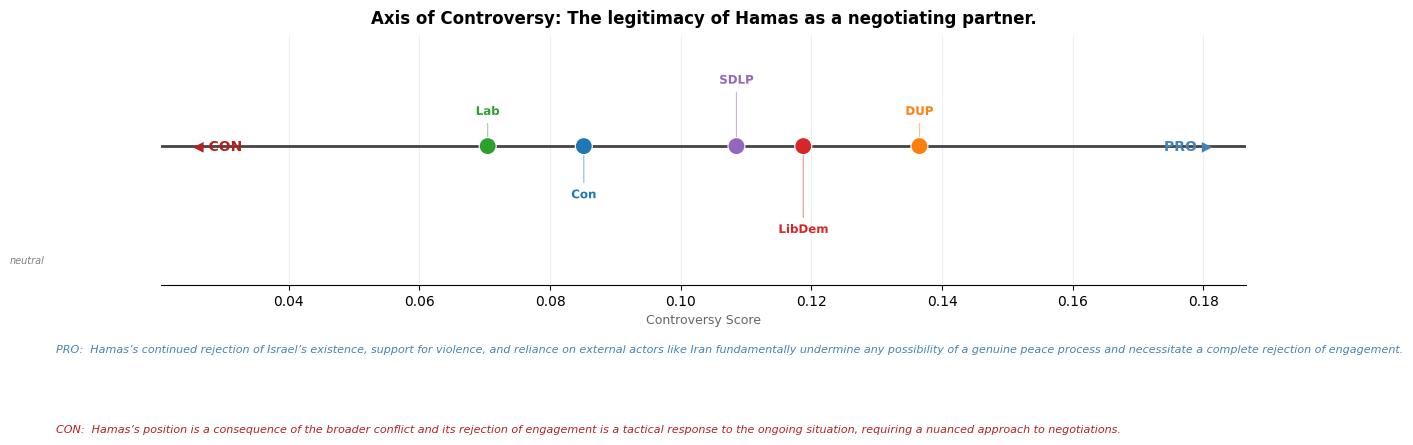

In [13]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[0])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()

gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[0], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "Lab",
  "SDLP",
  "Con",
  "DUP",
  "Lab"
]
Error generating gold standard ordering: Party mismatch.
Expected: ['Lab', 'DUP', 'Con', 'SDLP', 'LibDem']
Got: ['Lab', 'SDLP', 'Con', 'DUP', 'Lab']
Raw: [
  "Lab",
  "SDLP",
  "Con",
  "DUP",
  "Lab"
]
Raw LLM response: [
  "LibDem",
  "DUP",
  "SDLP",
  "Con",
  "Lab"
]
Raw LLM response: [
  "SDLP",
  "Con",
  "Lab",
  "DUP",
  "LibDem"
]
Raw LLM response: [
  "Con",
  "SDLP",
  "LibDem",
  "DUP"
]
Error generating gold standard ordering: Party mismatch.
Expected: ['Lab', 'SDLP', 'Con', 'LibDem', 'DUP']
Got: ['Con', 'SDLP', 'LibDem', 'DUP']
Raw: [
  "Con",
  "SDLP",
  "LibDem",
  "DUP"
]
Raw LLM response: [
  "SDLP",
  "LibDem",
  "Con",
  "Lab",
  "DUP"
]
Rank variance per party:
 LibDem    4.333333
DUP       2.333333
SDLP      1.333333
Con       1.000000
Lab       1.000000
dtype: float64
Predicted ordering: ['Lab', 'Con', 'LibDem', 'SDLP', 'DUP']
Gold standard ordering: ['SDLP', 'LibDem', 'Con', 'DUP', 'Lab']
{'spea

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.86s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


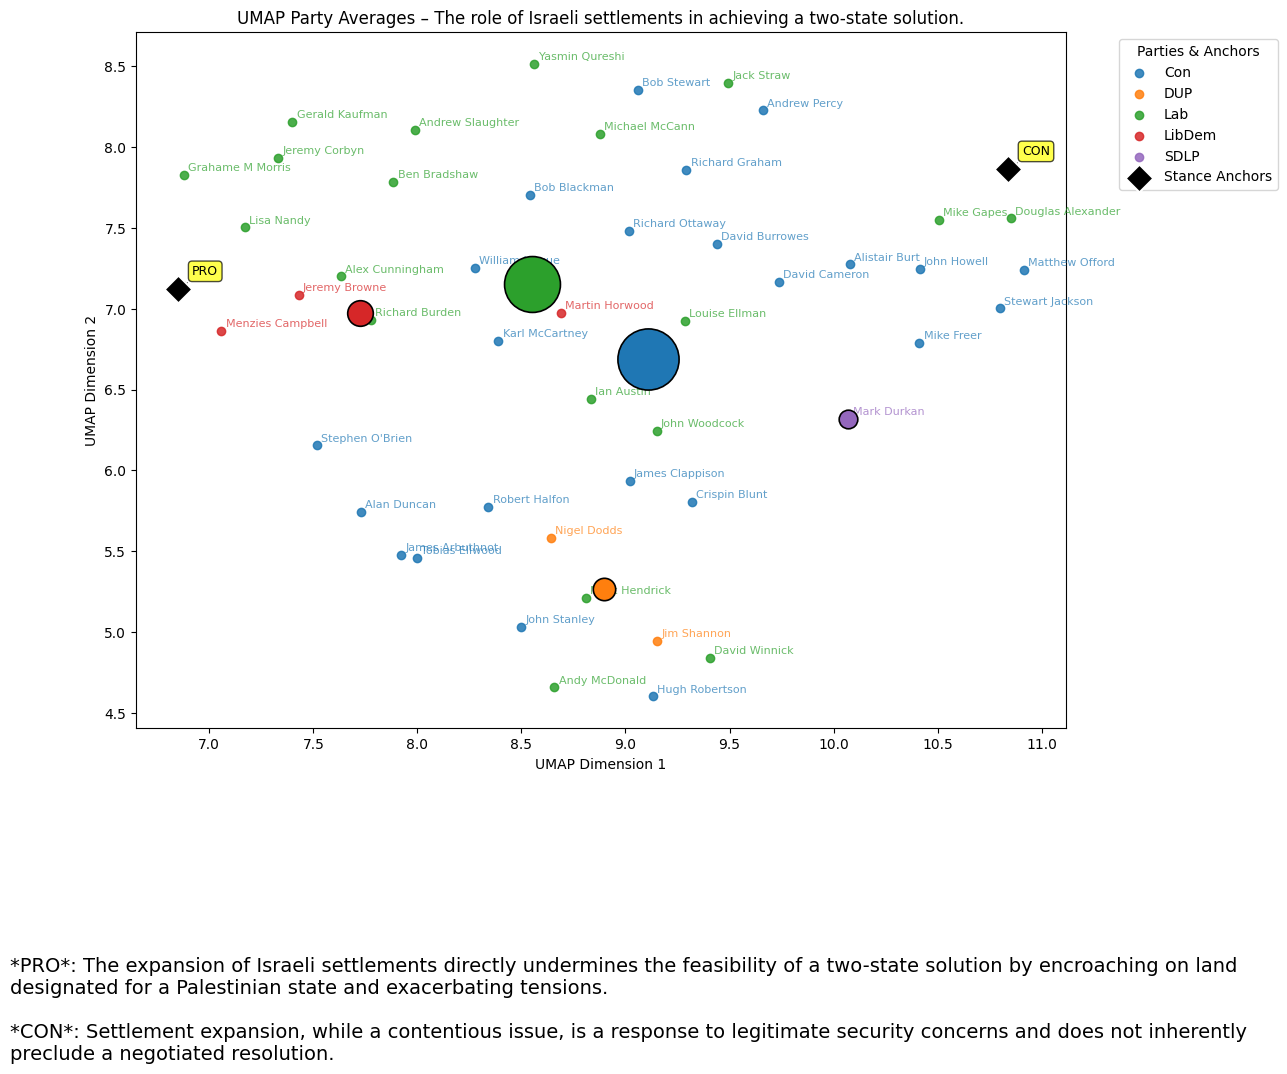

In [31]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

In [43]:
# compute controversy axis based on anchor 1 (pro) and anchor 0 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[1])

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = anchors[1]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:06<00:00,  3.03s/it]

Cosine similarity between anchor embeddings:
0.53004634


,party,controversy_score,issue
4,SDLP,0.029801,The role of Israeli settlements in achieving a...
2,Lab,0.095138,The role of Israeli settlements in achieving a...
0,Con,0.098826,The role of Israeli settlements in achieving a...
1,DUP,0.173207,The role of Israeli settlements in achieving a...
3,LibDem,0.180257,The role of Israeli settlements in achieving a...


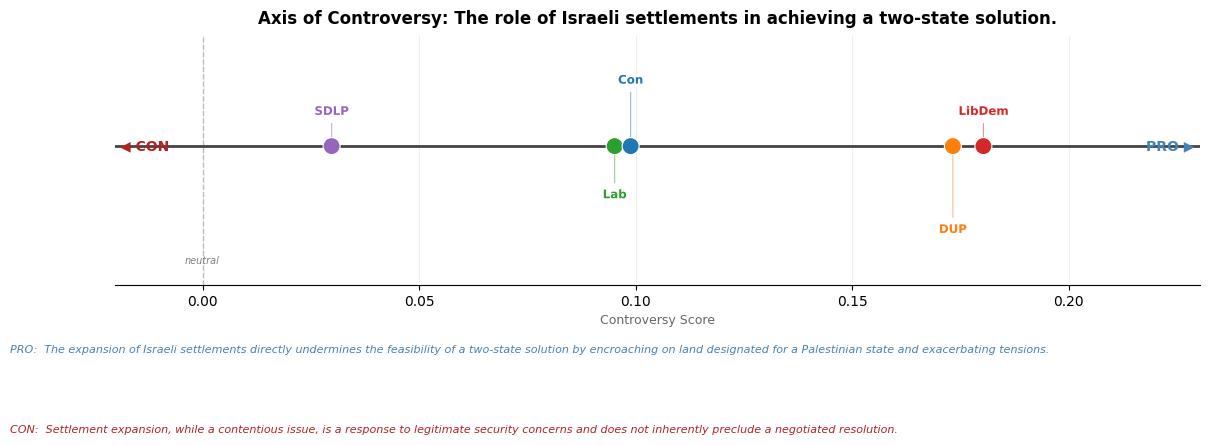

In [33]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[1])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[1], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "Lab",
  "SDLP",
  "LibDem",
  "Con",
  "DUP"
]
Raw LLM response: [
  "Con",
  "Lab",
  "LibDem",
  "DUP",
  "SDLP"
]
Raw LLM response: [
  "Con",
  "LibDem",
  "SDLP",
  "Lab",
  "DUP"
]
Raw LLM response: [
  "Con",
  "LibDem",
  "SDLP",
  "Lab",
  "DUP"
]
Raw LLM response: [
  "DUP",
  "SDLP",
  "Lab",
  "LibDem",
  "Con"
]
Rank variance per party:
 Lab       1.7
SDLP      1.5
LibDem    0.7
Con       3.8
DUP       3.0
dtype: float64
Predicted ordering: ['Con', 'LibDem', 'Lab', 'SDLP', 'DUP']
Gold standard ordering: ['Con', 'Lab', 'SDLP', 'LibDem', 'DUP']
{'spearman_rho': np.float64(0.7), 'spearman_p': np.float64(0.1881), 'kendall_tau': np.float64(0.6), 'kendall_p': np.float64(0.2333), 'lcs_ratio': 0.8, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.21s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


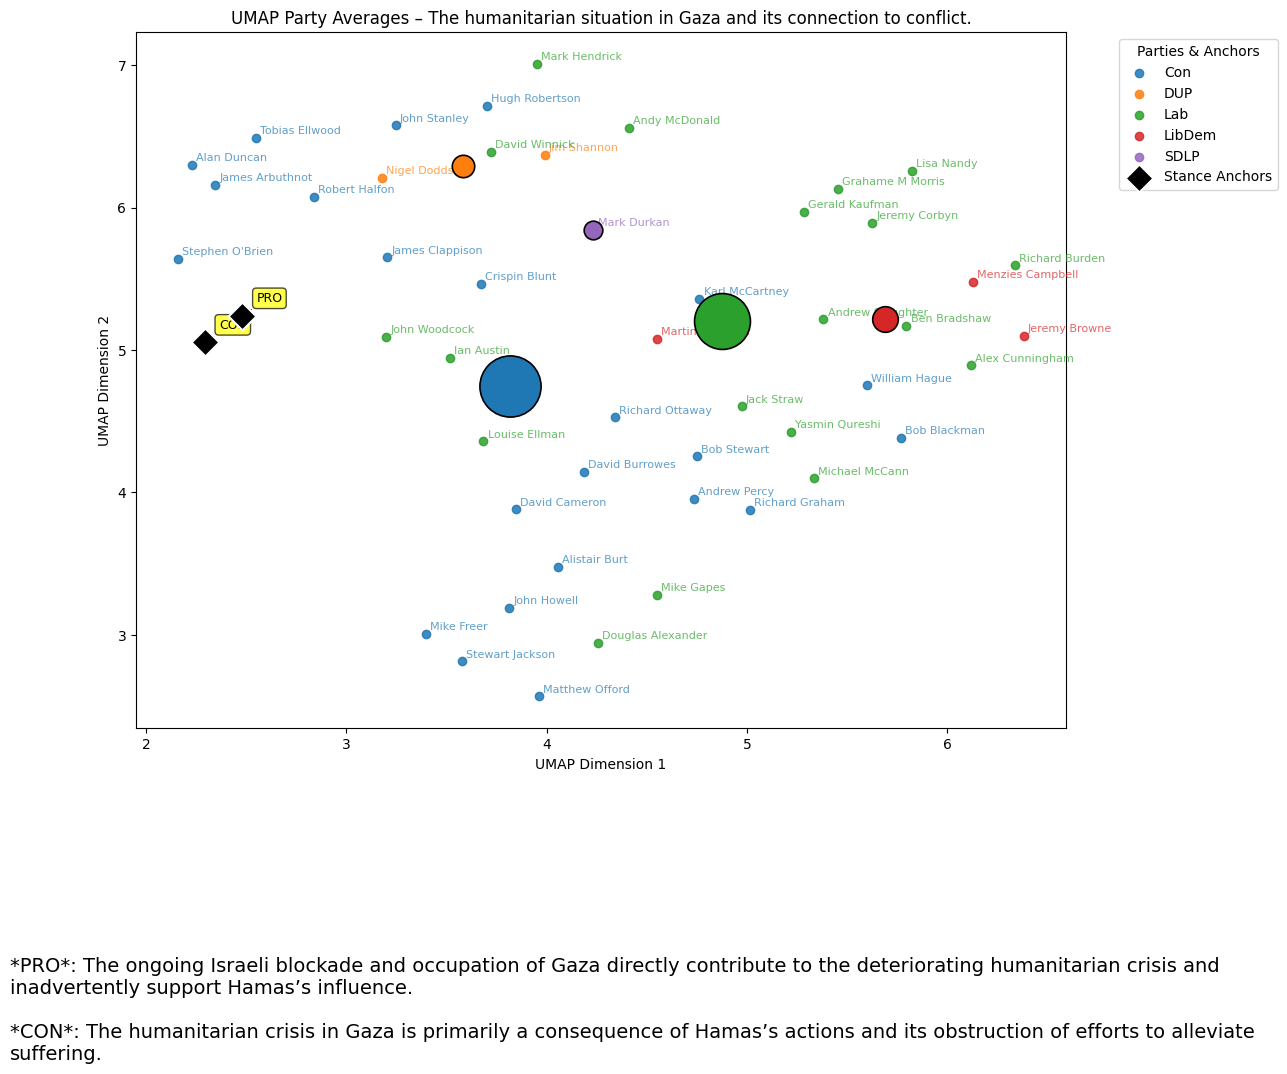

In [24]:
embeddings = uk.compute_umap_embeddings(topic, anchors[2])
uk.plot_umap_party_averages(embeddings, topic)

In [44]:
# compute controversy axis based on anchor 1 (pro) and anchor 0 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[2])

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)


issue = anchors[2]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:06<00:00,  3.41s/it]

Cosine similarity between anchor embeddings:
0.8491342


,party,controversy_score,issue
4,SDLP,-0.040531,The humanitarian situation in Gaza and its con...
2,Lab,0.014455,The humanitarian situation in Gaza and its con...
0,Con,0.018527,The humanitarian situation in Gaza and its con...
1,DUP,0.038299,The humanitarian situation in Gaza and its con...
3,LibDem,0.082322,The humanitarian situation in Gaza and its con...


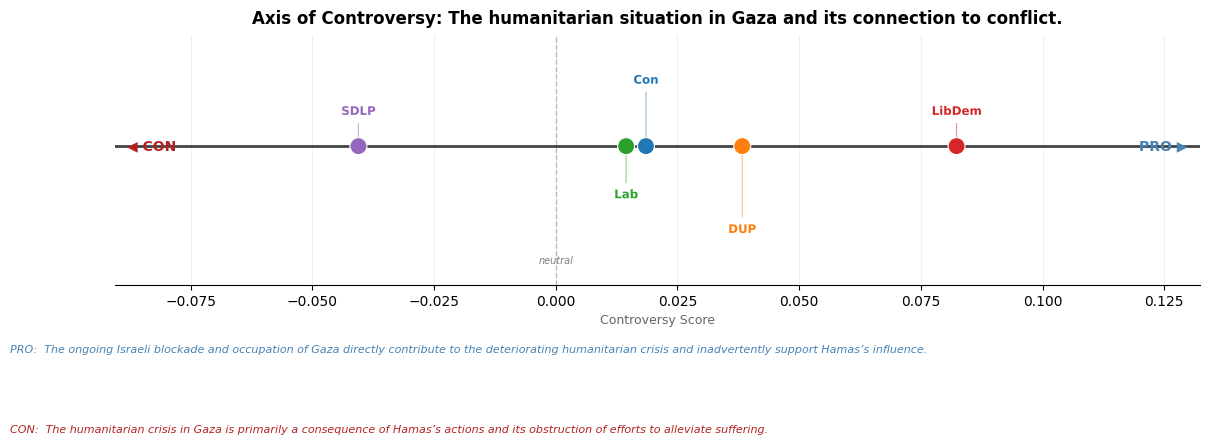

In [26]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[2])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[2], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "Lab",
  "Con",
  "LibDem",
  "SDLP",
  "DUP"
]
Predicted ordering: ['SDLP', 'Lab', 'Con', 'DUP', 'LibDem']
Gold standard ordering: ['Lab', 'Con', 'LibDem', 'SDLP', 'DUP']
{'spearman_rho': np.float64(0.2), 'spearman_p': np.float64(0.7471), 'kendall_tau': np.float64(0.2), 'kendall_p': np.float64(0.8167), 'lcs_ratio': 0.6, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.75s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


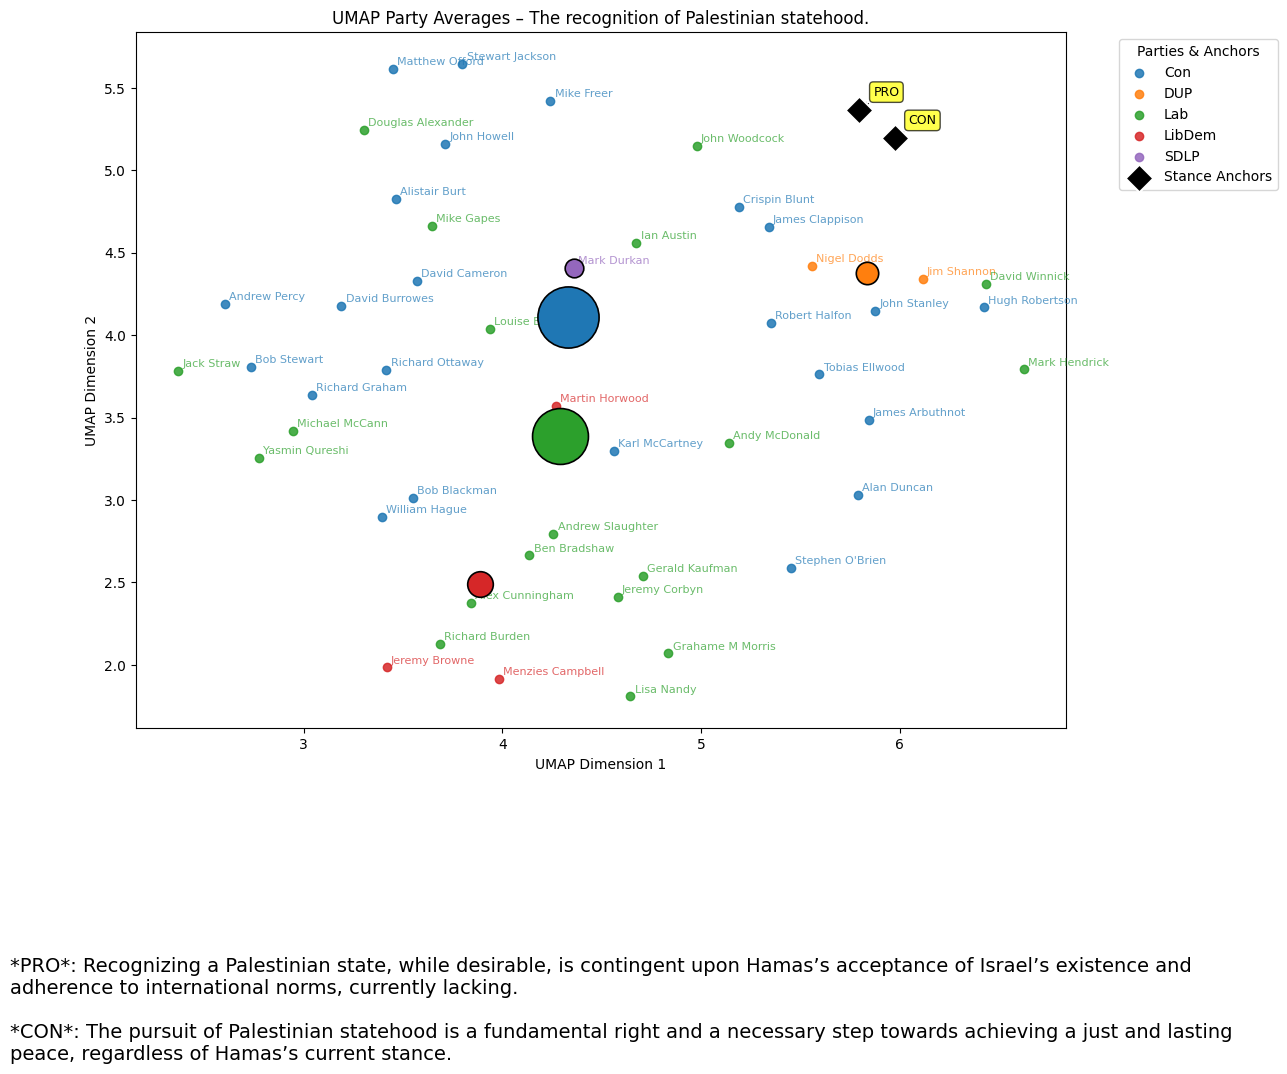

In [28]:
embeddings = uk.compute_umap_embeddings(topic, anchors[3])
uk.plot_umap_party_averages(embeddings, topic)

In [29]:
# compute controversy axis based on anchor 1 (pro) and anchor 0 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[3])
issue = anchors[3]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:09<00:00,  4.75s/it]


,party,controversy_score,issue
2,Lab,-0.047958,The recognition of Palestinian statehood.
0,Con,-0.017502,The recognition of Palestinian statehood.
3,LibDem,-0.017459,The recognition of Palestinian statehood.
4,SDLP,0.007920,The recognition of Palestinian statehood.
1,DUP,0.030403,The recognition of Palestinian statehood.


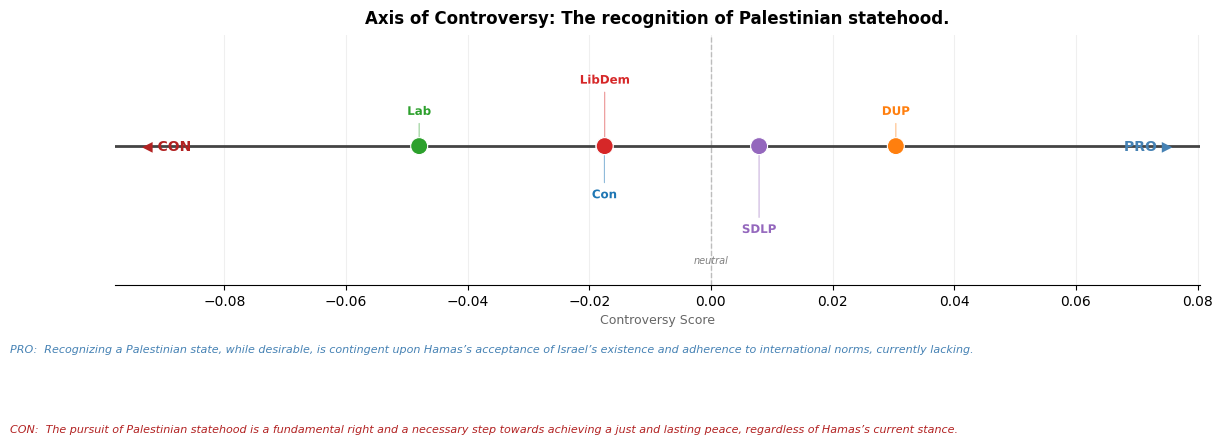

In [30]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[3])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[3], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "DUP",
  "Con",
  "Lab",
  "SDLP",
  "LibDem"
]
Predicted ordering: ['Lab', 'Con', 'LibDem', 'SDLP', 'DUP']
Gold standard ordering: ['DUP', 'Con', 'Lab', 'SDLP', 'LibDem']
{'spearman_rho': np.float64(-0.2), 'spearman_p': np.float64(0.7471), 'kendall_tau': np.float64(-0.2), 'kendall_p': np.float64(0.8167), 'lcs_ratio': 0.4, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.74s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


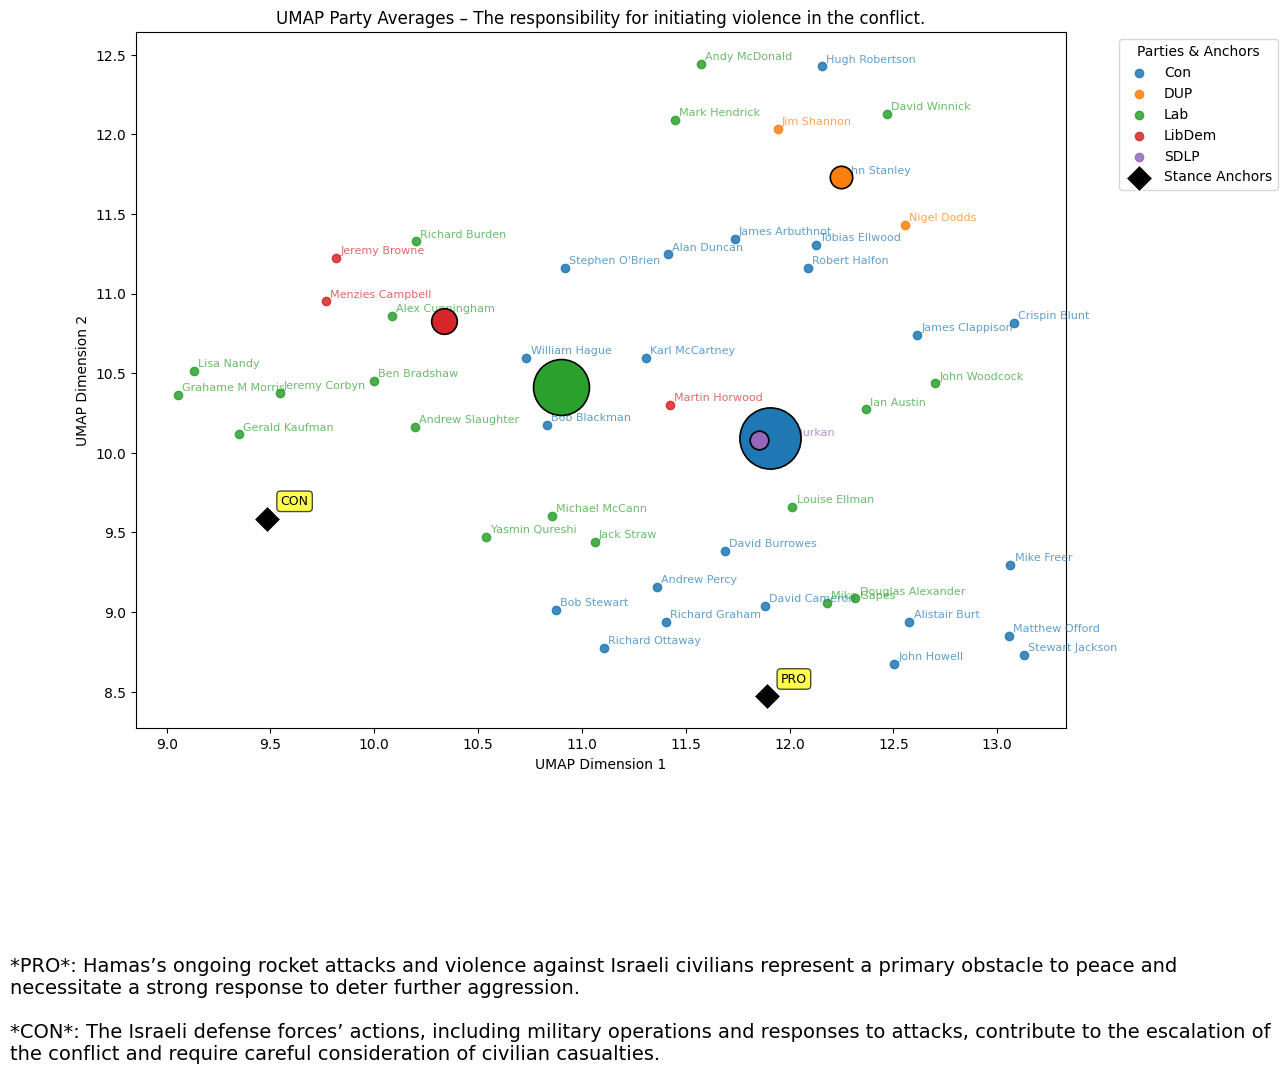

In [32]:
embeddings = uk.compute_umap_embeddings(topic, anchors[4])
uk.plot_umap_party_averages(embeddings, topic)

In [33]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[4])
issue = anchors[4]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:08<00:00,  4.40s/it]


,party,controversy_score,issue
4,SDLP,0.007934,The responsibility for initiating violence in ...
3,LibDem,0.052933,The responsibility for initiating violence in ...
2,Lab,0.081742,The responsibility for initiating violence in ...
1,DUP,0.151485,The responsibility for initiating violence in ...
0,Con,0.170311,The responsibility for initiating violence in ...


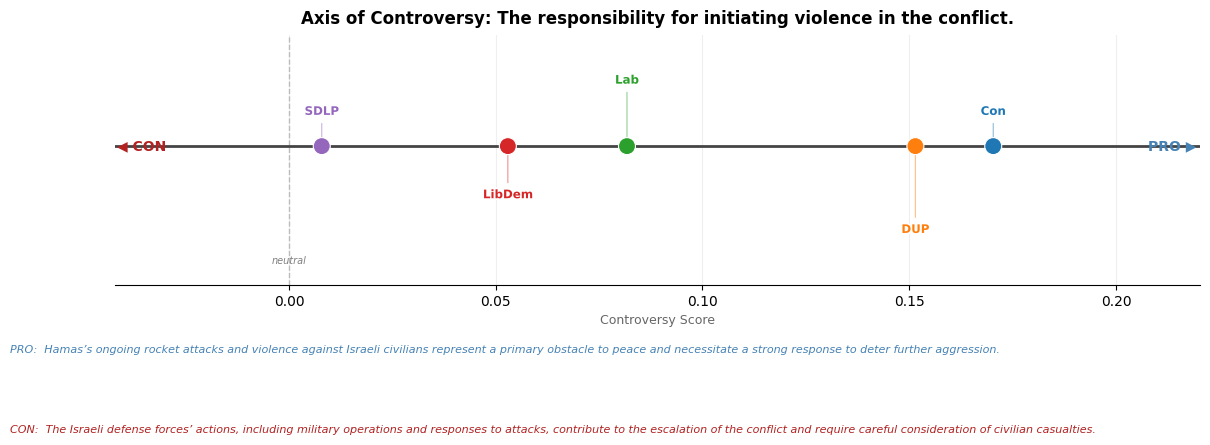

In [34]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[4])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[4], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "SDLP",
  "LibDem",
  "Lab",
  "DUP",
  "Con"
]
Predicted ordering: ['SDLP', 'LibDem', 'Lab', 'DUP', 'Con']
Gold standard ordering: ['SDLP', 'LibDem', 'Lab', 'DUP', 'Con']
{'spearman_rho': np.float64(1.0), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(1.0), 'kendall_p': np.float64(0.0167), 'lcs_ratio': 1.0, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:10<00:00,  5.24s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


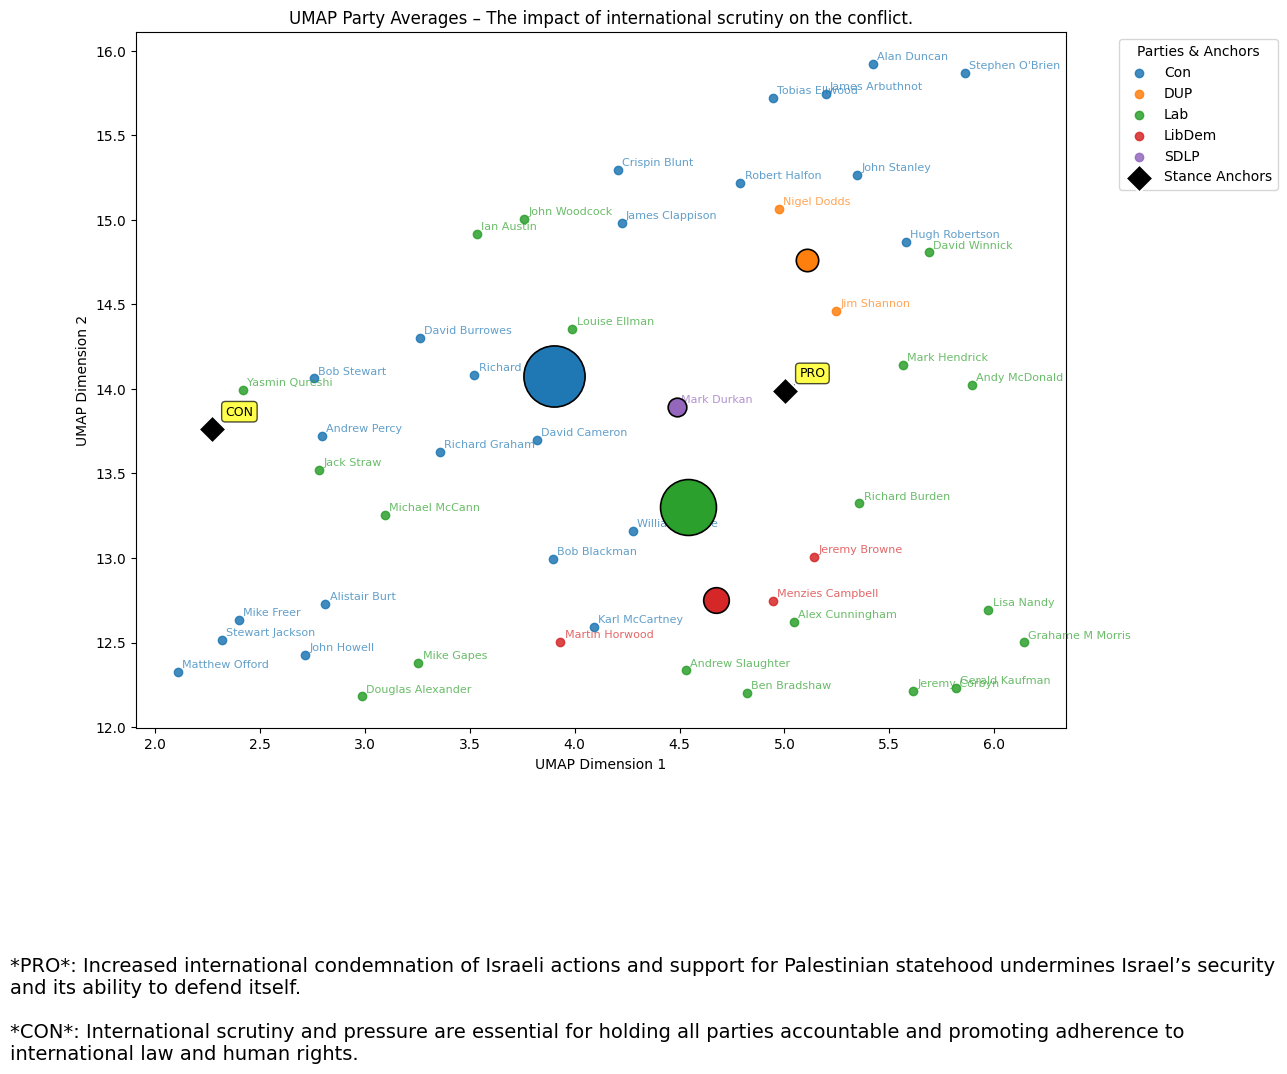

In [38]:
embeddings = uk.compute_umap_embeddings(topic, anchors[5])
uk.plot_umap_party_averages(embeddings, topic)

In [39]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[5])
issue = anchors[5]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:05<00:00,  2.59s/it]


,party,controversy_score,issue
2,Lab,0.169873,The impact of international scrutiny on the co...
0,Con,0.187037,The impact of international scrutiny on the co...
3,LibDem,0.233960,The impact of international scrutiny on the co...
4,SDLP,0.294400,The impact of international scrutiny on the co...
1,DUP,0.318592,The impact of international scrutiny on the co...


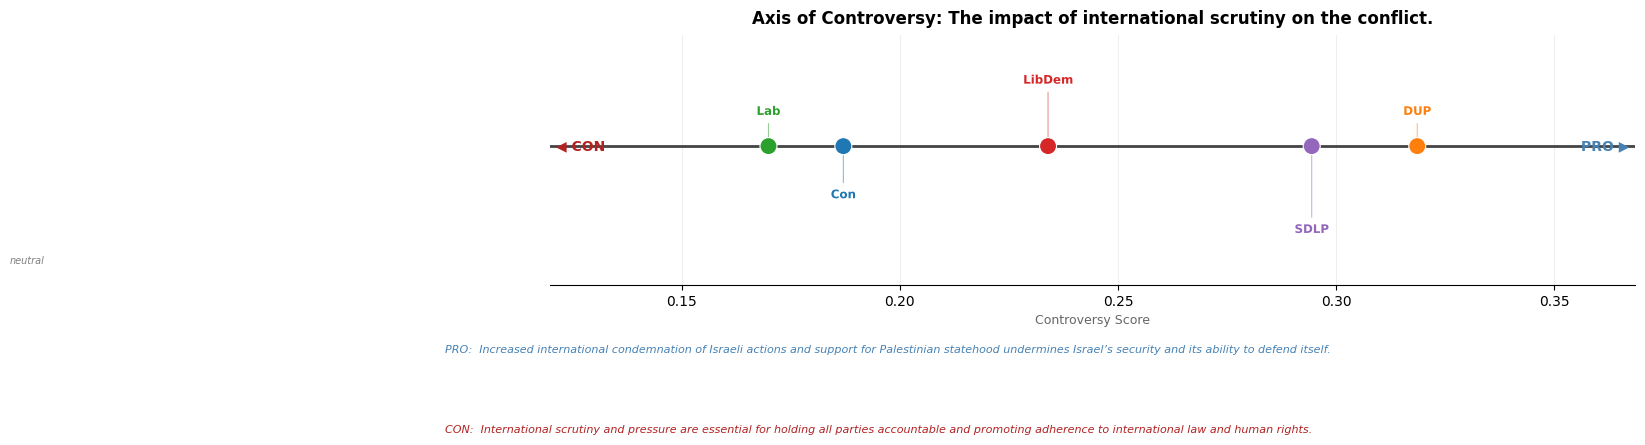

In [41]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[5])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[5], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Raw LLM response: [
  "Lab",
  "DUP",
  "Con",
  "SDLP",
  "LibDem"
]
Predicted ordering: ['Lab', 'Con', 'LibDem', 'SDLP', 'DUP']
Gold standard ordering: ['Lab', 'DUP', 'Con', 'SDLP', 'LibDem']
{'spearman_rho': np.float64(0.3), 'spearman_p': np.float64(0.6238), 'kendall_tau': np.float64(0.2), 'kendall_p': np.float64(0.8167), 'lcs_ratio': 0.6, 'n_parties': 5}


Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:12<00:00,  6.01s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


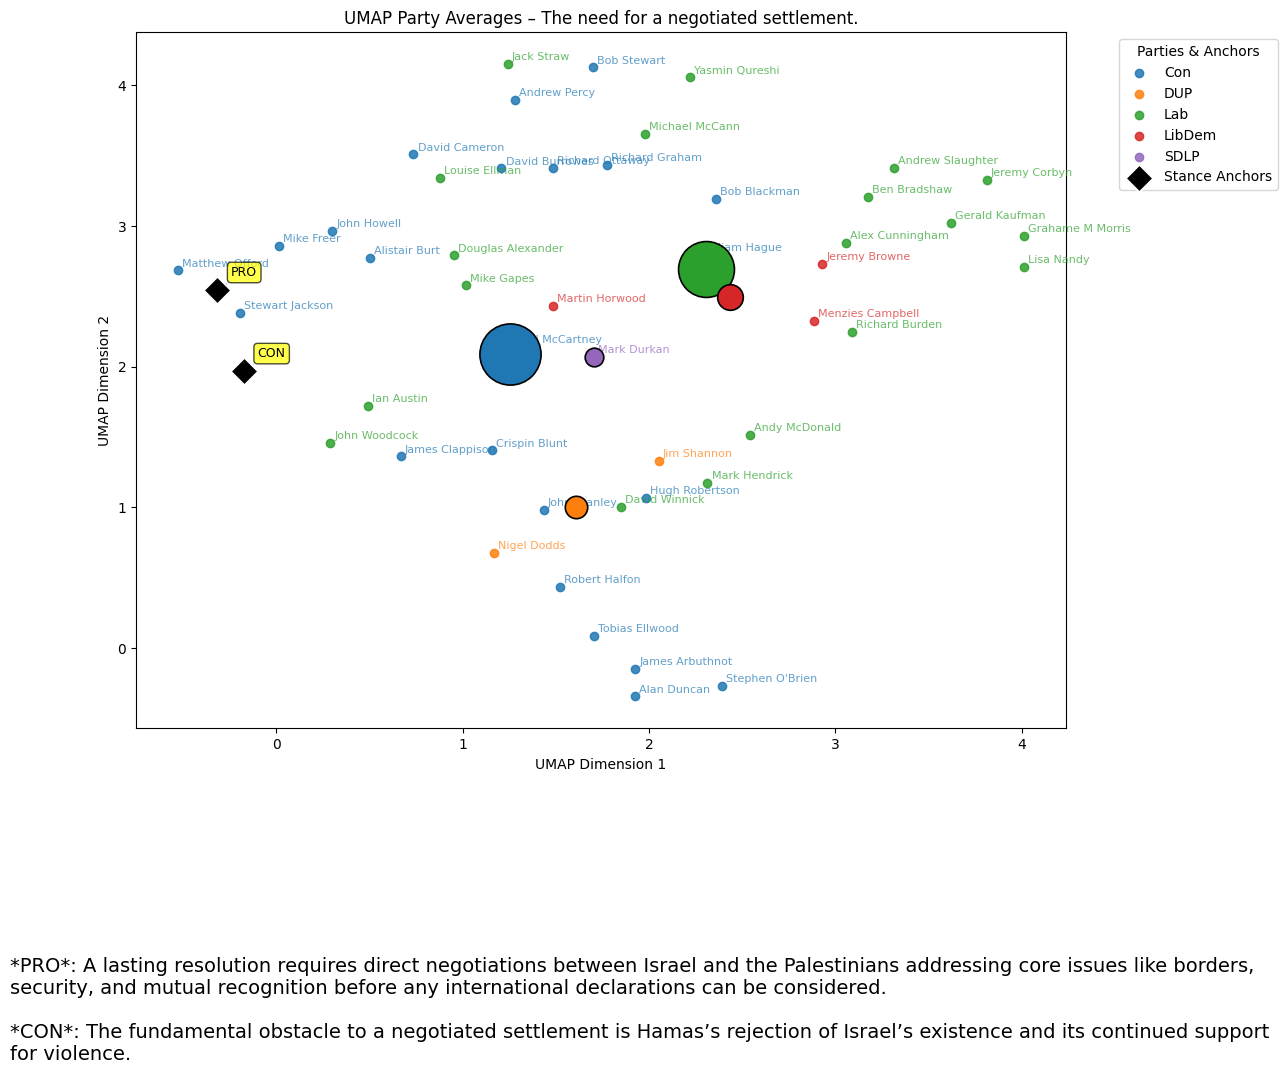

In [44]:
embeddings = uk.compute_umap_embeddings(topic, anchors[6])
uk.plot_umap_party_averages(embeddings, topic)

In [45]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[6])
issue = anchors[6]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: Gaza
['The politician advocates for the dismantling of Hamas in Gaza and opposes Palestinian statehood while Hamas remains in control, citing its rejection of Israel, use of violence, and support from Iran.', 'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.', 'The politician advocates for an immediate ceasefire based on mutual concessions between Israel, Hamas, and the Palestinian Authority, while criticizing Hamas’s actions and broader obstacles to a lasting peace agreement.', 'The Foreign Secretary believes that Israeli actions are undermining the possibility of a two-state solution and advocates for equal treatment of Palestinians and Israelis.', 'The politician advocates for holding elections in Gaza under a new, unified organization and expresses concern about Hamas’s obstruction of this process.', 'The politician advocates for a two-stat

Batches: 100%|██████████| 2/2 [00:10<00:00,  5.32s/it]


,party,controversy_score,issue
1,DUP,-0.214053,The need for a negotiated settlement.
0,Con,-0.178756,The need for a negotiated settlement.
4,SDLP,-0.172178,The need for a negotiated settlement.
2,Lab,-0.110240,The need for a negotiated settlement.
3,LibDem,-0.094455,The need for a negotiated settlement.


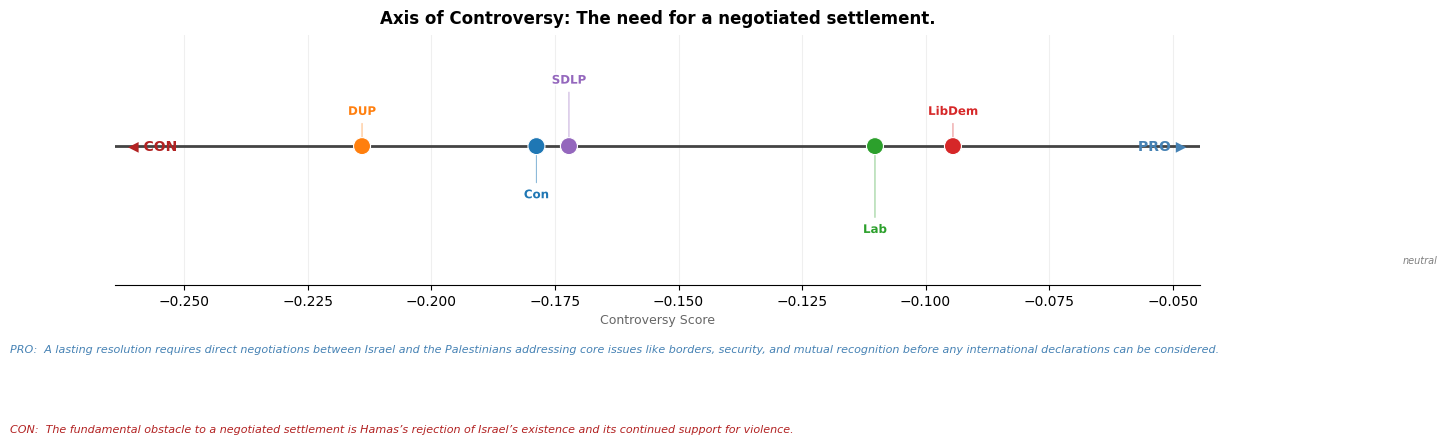

In [46]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[6])

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[6], years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

## Climate change

In [15]:
topic='climate change'
years = [2011, 2012, 2013, 2014]

In [ ]:
filtered_df= uk.filter_speeches(topic, years=years) 

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2011, 2012, 2013, 2014]: 1265
Classifying filtered speeches for topic: climate change


KeyboardInterrupt: 

In [16]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)   

In [33]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: climate change


In [34]:
# save anchors to json file for DEBUGGING purposes
with open(f'./../data/processed/anchors_{topic}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [17]:
# read anchors from json file for DEBUGGING purposes
with open(f'./../data/processed/anchors_{topic}.json', 'r') as f:
    anchors = json.load(f)

In [ ]:
general_anchors = {
    "topic": "The role of government intervention in accelerating the UK's transition to renewable energy",
    "pro": (
        "Ambitious government investment in renewable energy, binding emissions targets, "
        "and strong subsidies for clean technology are essential to meet climate goals, "
        "create green jobs, and reduce long-term dependence on fossil fuels."
    ),
    "con": (
        "Government-led renewable energy schemes impose excessive costs on consumers and "
        "industry, distort energy markets, and should be replaced by market-driven solutions "
        "that prioritize economic growth and energy security."
    )
}

In [18]:
anchors

[{'topic': 'The prioritization of economic growth and energy costs versus ambitious climate targets.',
  'pro': 'Rapid adoption of renewable energy sources is necessary to achieve emissions reduction targets and ensure long-term energy security.',
  'con': 'Prioritizing economic growth and stable energy costs over aggressive climate action is essential to maintain competitiveness and avoid harming consumers.'},
 {'topic': 'The role of government intervention versus private sector involvement in renewable energy development.',
  'pro': 'Government support, including investment and incentives, is crucial to stimulate growth and overcome market limitations in the renewable energy sector.',
  'con': 'Private sector involvement and existing building solutions are more effective and economically viable than government-backed renewable energy schemes.'},
 {'topic': 'The appropriate scale and type of renewable energy investment.',
  'pro': 'Expanding renewable energy infrastructure, particular

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.19s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


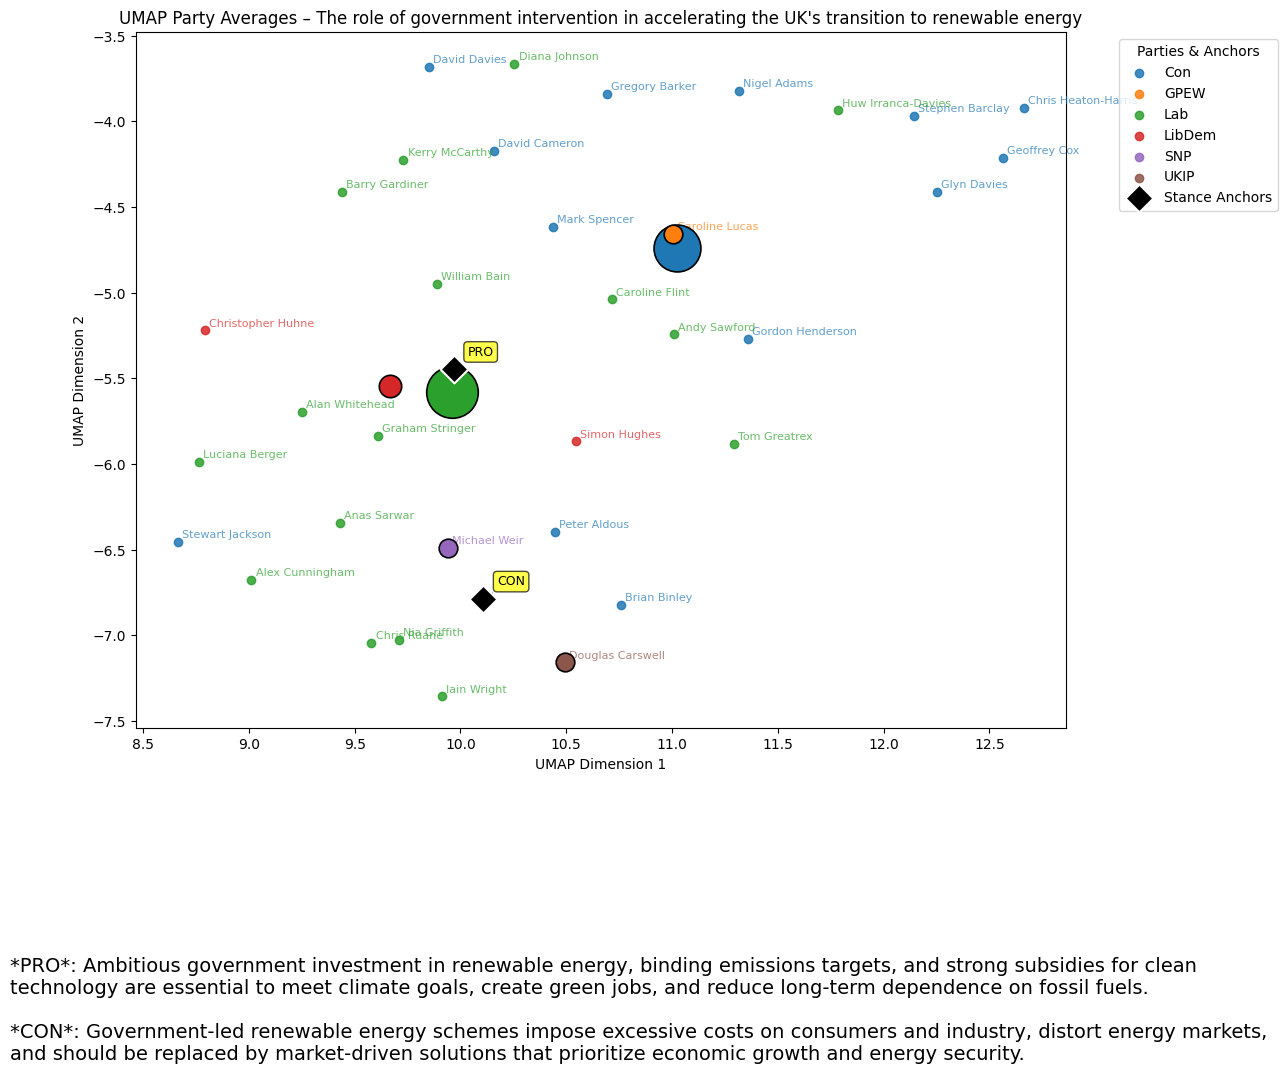

In [ ]:
embeddings = uk.compute_umap_embeddings(topic, general_anchors)
uk.plot_umap_party_averages(embeddings, topic)

In [ ]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)
issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change
['The politician favors a greater reliance on onshore wind and biofuels while opposing devolved decision-making regarding energy policy.', 'The politician opposes the expansion of onshore wind farms and prioritizes preserving the landscape.', 'The politician supports the expansion of renewable energy infrastructure, particularly wind farms, while expressing concern about the potential negative impacts on landowners and the rising cost of energy for consumers.', 'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.', 'He believes the Conservative-Liberal Democrat government’s actions have hindered investment in renewable energy, negatively impacting the UK’s position in green technology.', 'The politician believes the government’s approach to renewable energy is failing, hindering progress, and damaging the UK’s ability to meet its environmental targets.', 'The politician e

Batches: 100%|██████████| 2/2 [00:04<00:00,  2.35s/it]


,party,controversy_score,issue
5,UKIP,-0.093971,The role of government intervention in acceler...
4,SNP,-0.038986,The role of government intervention in acceler...
0,Con,-0.035085,The role of government intervention in acceler...
3,LibDem,-0.028359,The role of government intervention in acceler...
2,Lab,0.037840,The role of government intervention in acceler...
1,GPEW,0.060855,The role of government intervention in acceler...


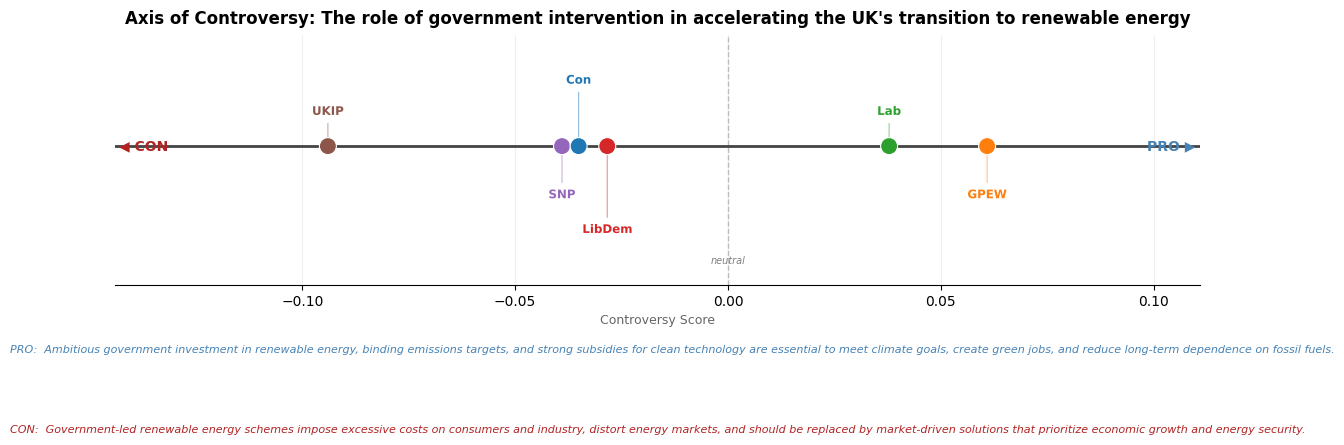

In [ ]:
# plot controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

In [ ]:
# evaluation of the ordering of parties along the controversy axis
parties = party_df['party'].tolist()


gold_ordering = uk.generate_gold_standard(parties=parties, anchors=general_anchors, years=years)

print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)

metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

KeyboardInterrupt: 

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:03<00:00,  1.84s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


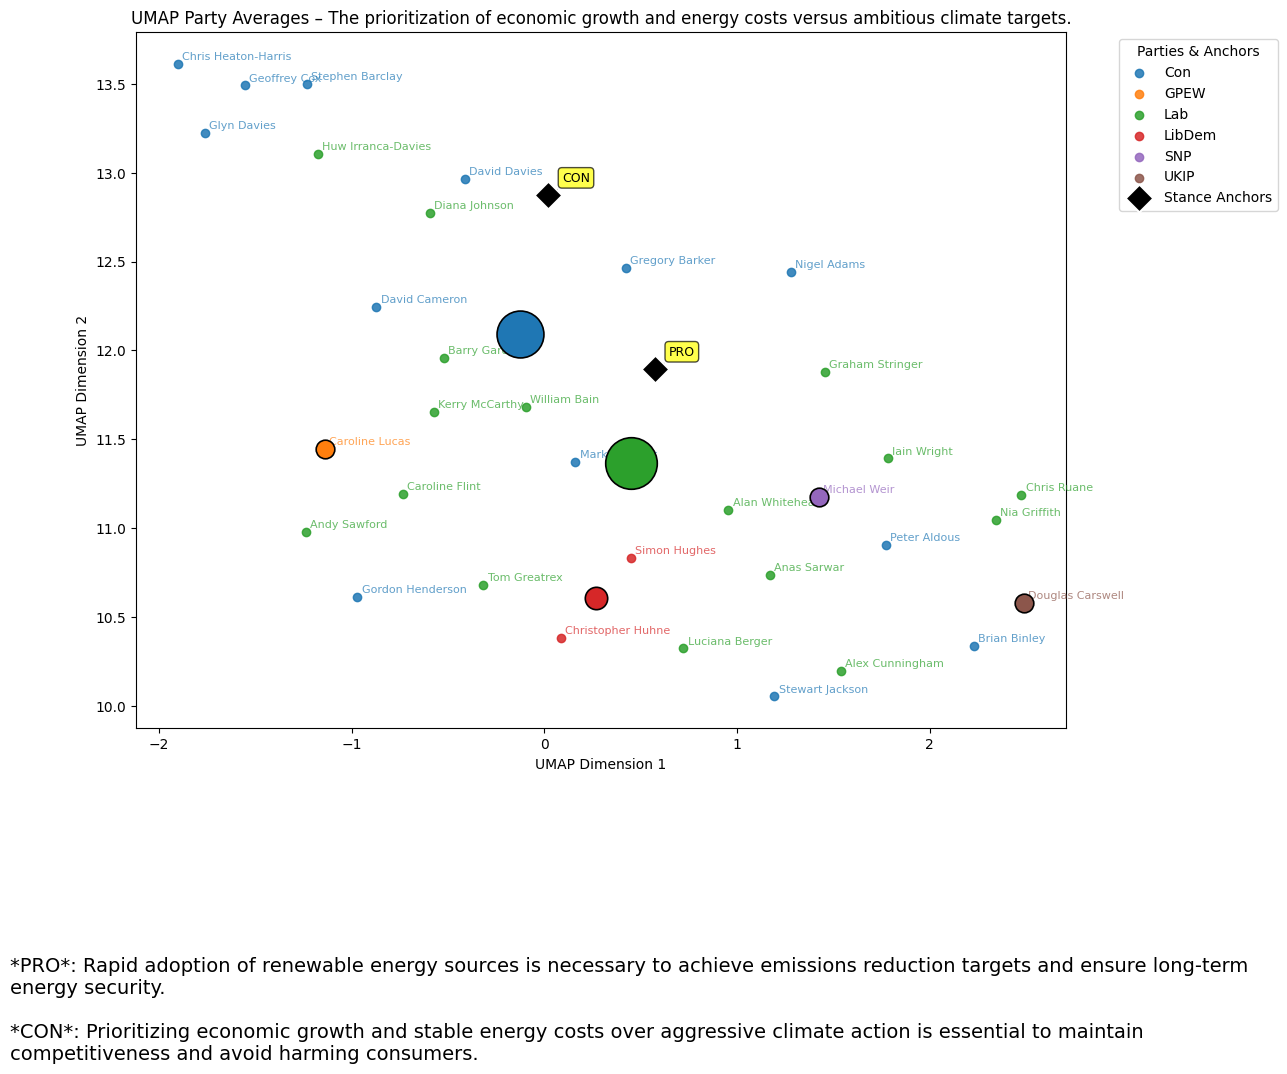

In [98]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [ ]:
# generating controversy axis based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[0])
issue = anchors[0]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change
['The politician favors a greater reliance on onshore wind and biofuels while opposing devolved decision-making regarding energy policy.', 'The politician opposes the expansion of onshore wind farms and prioritizes preserving the landscape.', 'The politician supports the expansion of renewable energy infrastructure, particularly wind farms, while expressing concern about the potential negative impacts on landowners and the rising cost of energy for consumers.', 'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.', 'He believes the Conservative-Liberal Democrat government’s actions have hindered investment in renewable energy, negatively impacting the UK’s position in green technology.', 'The politician believes the government’s approach to renewable energy is failing, hindering progress, and damaging the UK’s ability to meet its environmental targets.', 'The politician e

Batches: 100%|██████████| 2/2 [00:03<00:00,  1.95s/it]


,party,controversy_score,issue
4,SNP,-0.009083,The prioritization of economic growth and ener...
2,Lab,-0.037455,The prioritization of economic growth and ener...
3,LibDem,-0.045387,The prioritization of economic growth and ener...
0,Con,-0.073641,The prioritization of economic growth and ener...
5,UKIP,-0.079066,The prioritization of economic growth and ener...
1,GPEW,-0.091266,The prioritization of economic growth and ener...


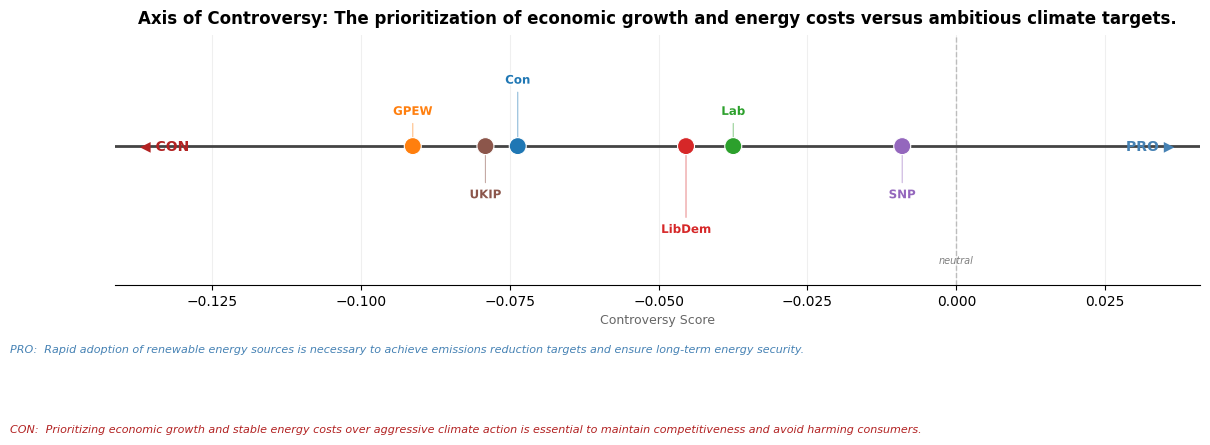

In [101]:
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[0])

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.30s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


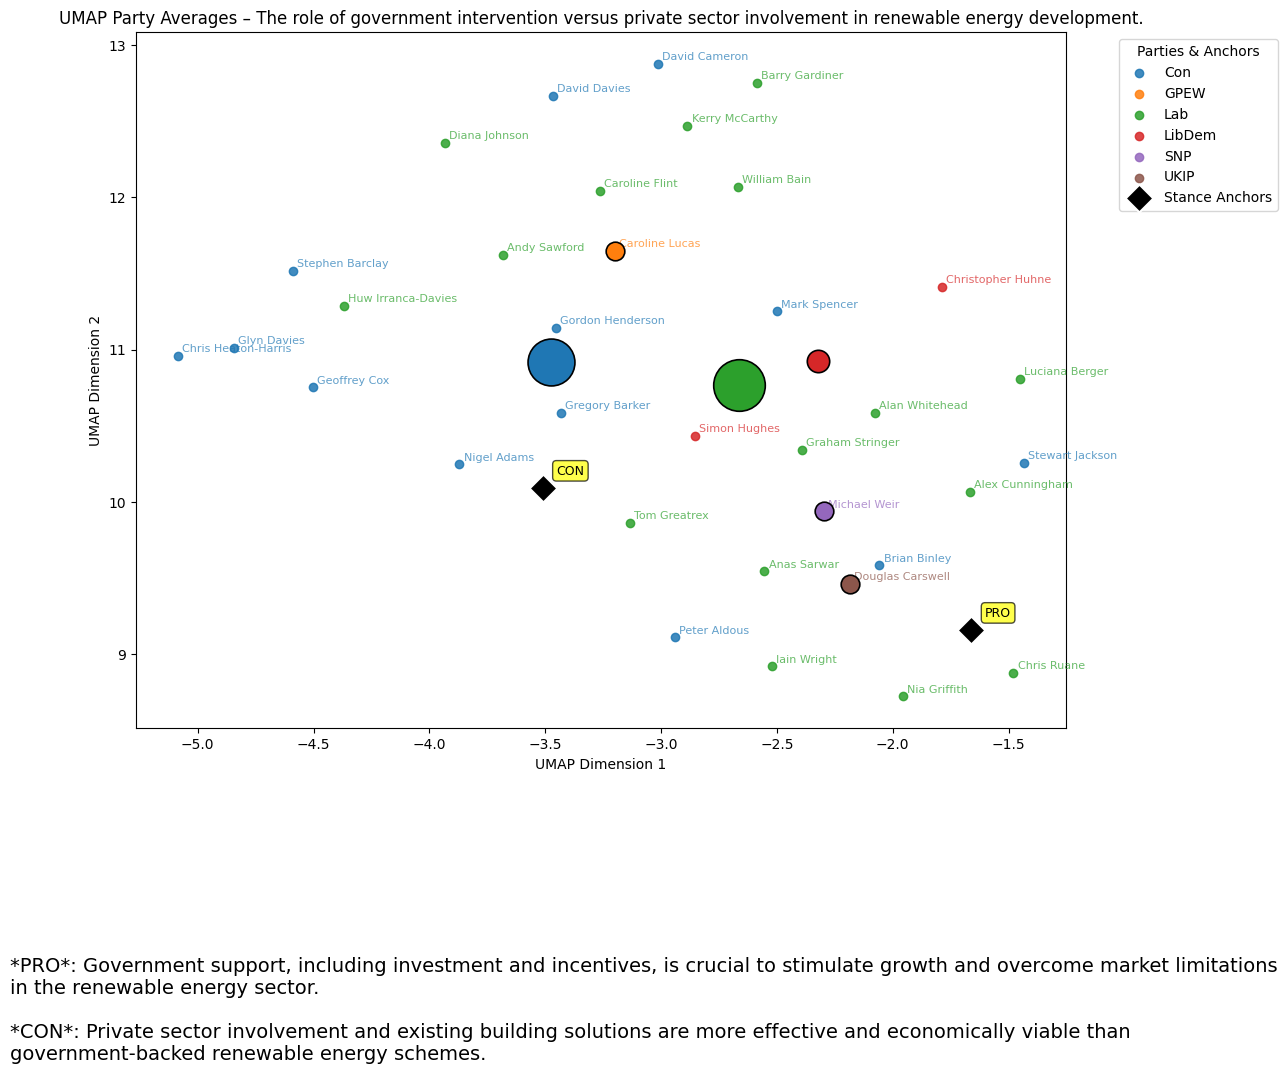

In [22]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

In [ ]:
# Compute embeddings for speakers and anchors
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[1])
issue = anchors[1]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)

# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change
['The politician favors a greater reliance on onshore wind and biofuels while opposing devolved decision-making regarding energy policy.', 'The politician opposes the expansion of onshore wind farms and prioritizes preserving the landscape.', 'The politician supports the expansion of renewable energy infrastructure, particularly wind farms, while expressing concern about the potential negative impacts on landowners and the rising cost of energy for consumers.', 'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.', 'He believes the Conservative-Liberal Democrat government’s actions have hindered investment in renewable energy, negatively impacting the UK’s position in green technology.', 'The politician believes the government’s approach to renewable energy is failing, hindering progress, and damaging the UK’s ability to meet its environmental targets.', 'The politician e

Batches: 100%|██████████| 2/2 [00:04<00:00,  2.10s/it]


,party,controversy_score,issue
4,SNP,0.070655,The role of government intervention versus pri...
2,Lab,0.034806,The role of government intervention versus pri...
1,GPEW,0.026096,The role of government intervention versus pri...
0,Con,-0.015063,The role of government intervention versus pri...
5,UKIP,-0.018193,The role of government intervention versus pri...
3,LibDem,-0.046471,The role of government intervention versus pri...


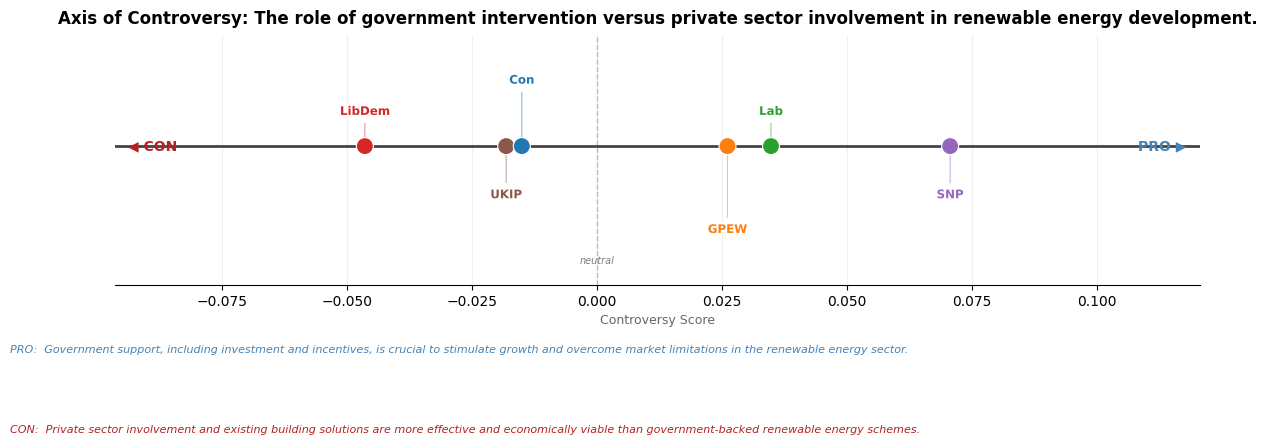

In [29]:
# visualize controversy axis with speakers projected onto it
uk.plot_axis_of_controversy(party_df, topic, issue=issue, anchors=anchors[1])

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.01s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


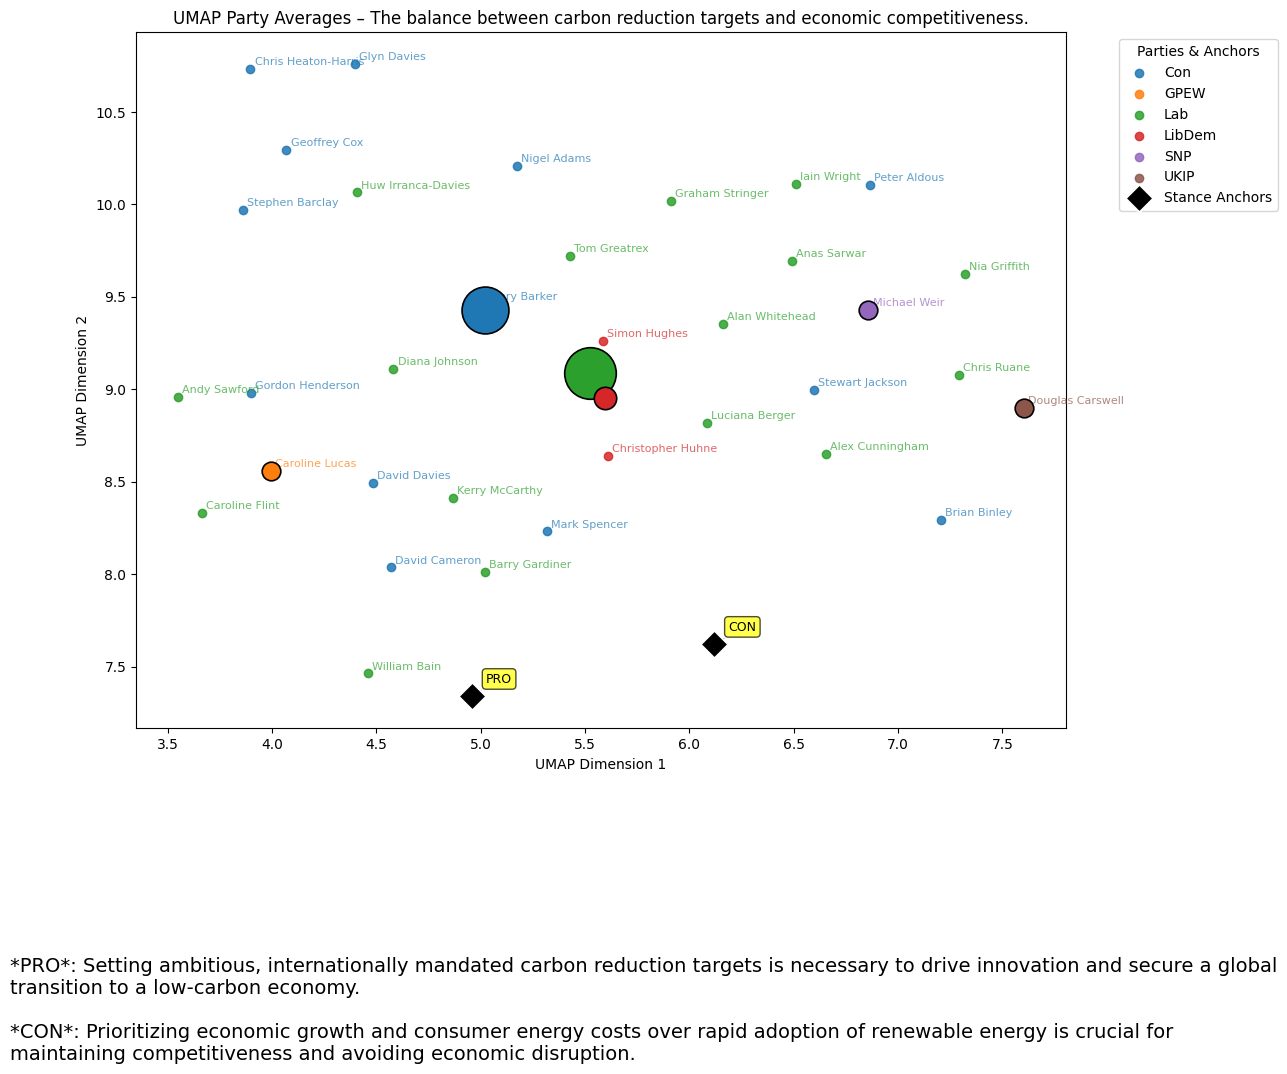

In [11]:
embeddings = uk.compute_umap_embeddings(topic, anchors[3])
uk.plot_umap_party_averages(embeddings, topic)

In [11]:
# controversy axis based on anchor 3 (pro) and anchor 4 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[3])
issue = anchors[3]['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)
# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: climate change
['The politician favors a greater reliance on onshore wind and biofuels while opposing devolved decision-making regarding energy policy.', 'The politician opposes the expansion of onshore wind farms and prioritizes preserving the landscape.', 'The politician supports the expansion of renewable energy infrastructure, particularly wind farms, while expressing concern about the potential negative impacts on landowners and the rising cost of energy for consumers.', 'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.', 'He believes the Conservative-Liberal Democrat government’s actions have hindered investment in renewable energy, negatively impacting the UK’s position in green technology.', 'The politician believes the government’s approach to renewable energy is failing, hindering progress, and damaging the UK’s ability to meet its environmental targets.', 'The politician e

Batches: 100%|██████████| 2/2 [00:04<00:00,  2.00s/it]


,party,controversy_score,issue
5,UKIP,-0.195989,The balance between carbon reduction targets a...
1,GPEW,-0.195004,The balance between carbon reduction targets a...
0,Con,-0.166722,The balance between carbon reduction targets a...
4,SNP,-0.165576,The balance between carbon reduction targets a...
3,LibDem,-0.100354,The balance between carbon reduction targets a...
2,Lab,-0.061895,The balance between carbon reduction targets a...


In [12]:
issue

'The balance between carbon reduction targets and economic competitiveness.'

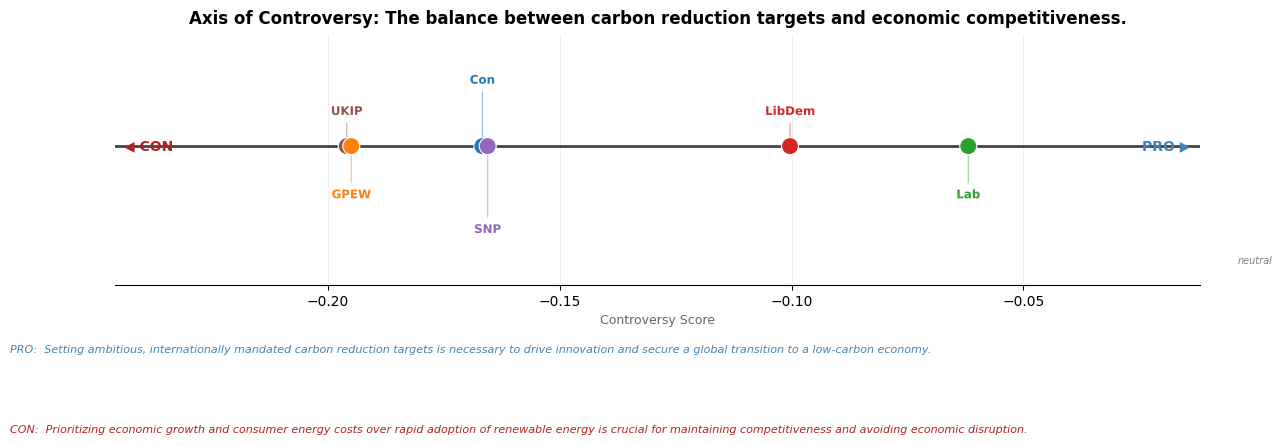

In [13]:
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=anchors[3])

In [14]:
parties = party_df['party'].tolist()
parties

['UKIP', 'GPEW', 'Con', 'SNP', 'LibDem', 'Lab']

In [17]:
gold_ordering = uk.generate_gold_standard(parties=parties, anchors=anchors[3], years=years)
gold_ordering

Raw LLM response: ["Con", "LibDem", "SNP", "UKIP", "GPEW", "Lab"]
Extracted JSON array: ["Con", "LibDem", "SNP", "UKIP", "GPEW", "Lab"]


['Con', 'LibDem', 'SNP', 'UKIP', 'GPEW', 'Lab']

In [18]:
print("Predicted ordering:", parties)
print("Gold standard ordering:", gold_ordering)
metrics = uk.evaluate_ordering(pred_ordering=parties, gold_ordering=gold_ordering)
print(metrics)

Predicted ordering: ['UKIP', 'GPEW', 'Con', 'SNP', 'LibDem', 'Lab']
Gold standard ordering: ['Con', 'LibDem', 'SNP', 'UKIP', 'GPEW', 'Lab']
{'spearman_rho': np.float64(0.0857), 'spearman_p': np.float64(0.8717), 'kendall_tau': np.float64(0.0667), 'kendall_p': np.float64(1.0), 'lcs_ratio': 0.5, 'n_parties': 6}


## Immigration

In [40]:
topic = "immigration"
years = [2011, 2012, 2013, 2014]

In [14]:
df1['policyarea'].unique()

array([16, 19, 18,  7,  8])

In [17]:
df1.shape

(543260, 7)

In [41]:
df = pd.read_csv('./../data/raw/ParlEE_UK_plenary_speeches.csv')

C:\Users\FedeF\AppData\Local\Temp\ipykernel_1832\2326606223.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./../data/raw/ParlEE_UK_plenary_speeches.csv')


In [23]:
df.columns

Index(['instance_id', 'date', 'agenda', 'speechnumber', 'sentencenumber',
       'speaker', 'party', 'text', 'parliament', 'iso3country', 'chair', 'eu',
       'policyarea', 'cmp_party'],
      dtype='object')

In [16]:
df.shape

(6767026, 14)

In [42]:
# convert df date column into a 'year' column
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# drop from df the columns that are not columns of df1
df = df[df.columns.intersection(df1.columns)]

In [43]:
df.columns, df1.columns

(Index(['date', 'agenda', 'speaker', 'party', 'text', 'policyarea', 'year'], dtype='object'),
 Index(['date', 'agenda', 'speaker', 'party', 'text', 'policyarea', 'year'], dtype='object'))

In [44]:
# DEBUG----------
StanceDetector = reload_detector()
# ------------------
uk=StanceDetector(df, records, random_seed=random_seed)

c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [45]:
filtered_df= uk.filter_speeches(topic, years=years) 
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

Filtering speeches for topic: immigration
Number of speeches after filtering for topic 'immigration' in years [2011, 2012, 2013, 2014]: 4525
Classifying filtered speeches for topic: immigration
"Number of opinionated speeches for immigration: 513
Summarization completed for topic: immigration


In [52]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)  

In [51]:
general_anchors = {
    "topic": "The balance between national immigration control and international humanitarian obligations",
    "pro": (
        "International legal frameworks, including human rights law and refugee conventions, "
        "must constrain domestic immigration policy; asylum seekers and refugees have "
        "enforceable rights that take precedence over numerical targets and border enforcement."
    ),
    "con": (
        "Elected governments must retain sovereign control over immigration levels and "
        "enforcement, free from interference by international courts; sustainable public "
        "services and community cohesion require firm limits on net migration and "
        "swift removal of those without legal status."
    )
}

Computing UMAP embeddings for topic: immigration


Batches: 100%|██████████| 4/4 [00:11<00:00,  2.97s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


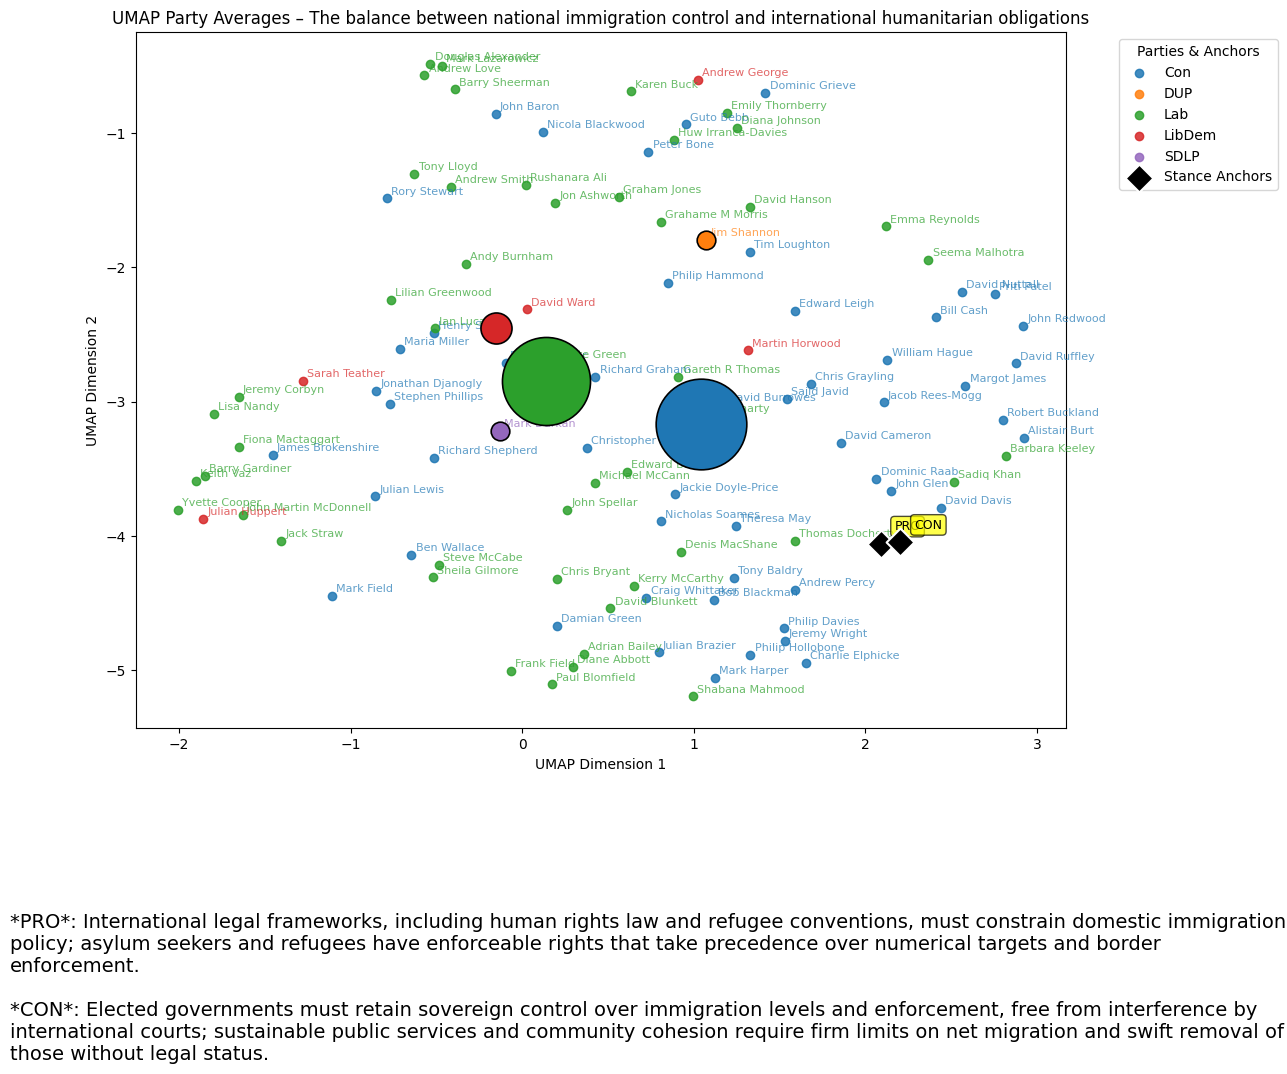

In [53]:
embeddings = uk.compute_umap_embeddings(topic, general_anchors)
uk.plot_umap_party_averages(embeddings, topic)

In [54]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)


# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: immigration
['The politician supports stricter law enforcement and greater Home Office control over immigration policy.', 'The politician advocates for British laws independent of European Court of Human Rights rulings and expresses concern regarding potential legal challenges stemming from immigration policies.', 'The politician advocates for significantly reduced immigration through measures including severing ties between foreign workers and citizenship, prioritizing deportation of criminals, and strict enforcement of asylum rules.', 'The politician advocates for strict controls on immigration, prioritizing border security and questioning the influence of international legal bodies on domestic decision-making.', 'The politician advocates for stricter immigration controls, particularly regarding short-term visas, and expresses concern about the impact of immigration on communities and the need for greater transparency in government processes.', 'The po

Batches: 100%|██████████| 4/4 [00:11<00:00,  2.99s/it]

Cosine similarity between anchor embeddings:
0.6791059


,party,controversy_score,issue
4,SDLP,-0.056965,The balance between national immigration contr...
3,LibDem,-0.026396,The balance between national immigration contr...
0,Con,-0.007320,The balance between national immigration contr...
2,Lab,-0.005862,The balance between national immigration contr...
1,DUP,0.094024,The balance between national immigration contr...


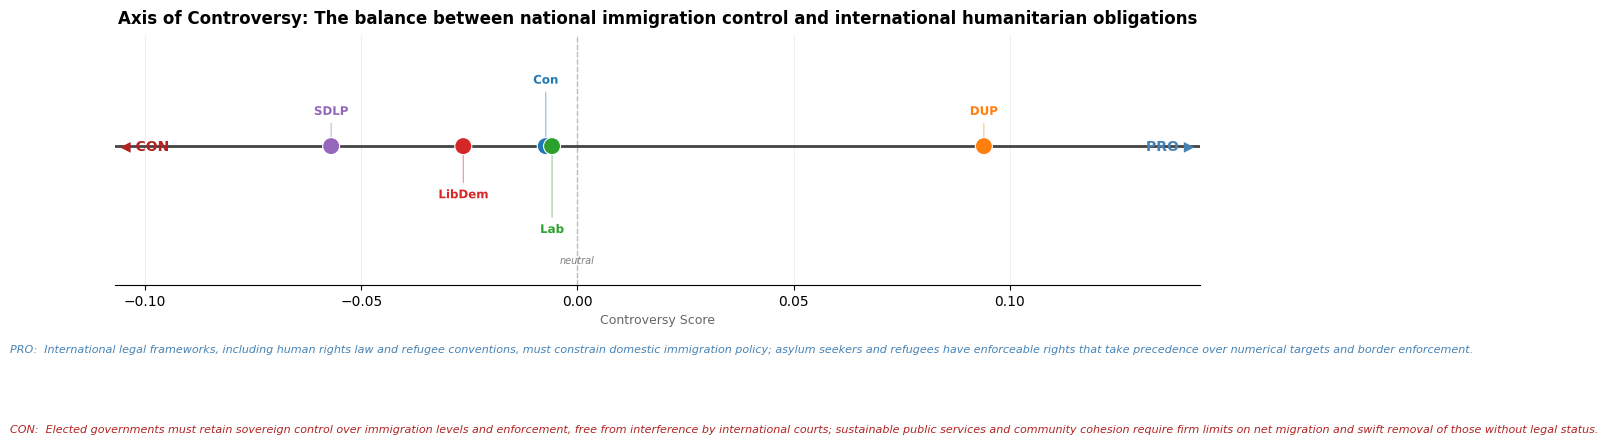

In [55]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

## Nuclear energy

In [ ]:
topic = 'nuclear'
years = [2011, 2012, 2013, 2014]

In [ ]:
filtered_df= uk.filter_speeches(topic, years=years) 

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

Filtering speeches for topic: nuclear
Number of speeches after filtering for topic 'nuclear' in years [2011, 2012, 2013, 2014]: 597
Classifying filtered speeches for topic: nuclear
"Number of opinionated speeches for nuclear: 43
Summarization completed for topic: nuclear


In [ ]:
summarizations

,summary,party,speaker
0,The politician opposes the development of nucl...,Con,David Cameron
1,The politician believes nuclear energy should ...,Lab,Paul Flynn
2,The politician opposes the use of nuclear ener...,Con,Tony Baldry
3,The politician believes nuclear energy should ...,LibDem,Christopher Huhne
4,The politician opposes the development of new ...,LibDem,Martin Horwood
5,The politician opposes nuclear energy due to c...,GPEW,Caroline Lucas
6,The politician expresses concerns regarding th...,Con,Mike Weatherley
7,The politician opposes measures that could res...,Lab,Alan Whitehead
8,The politician opposes the use of nuclear ener...,Lab,Jeremy Corbyn
9,The politician opposes the expansion of nuclea...,Con,Charles Hendry


Note: Per questioni di mantenimento probabilmente sarebbe meglio salvare le summarization su file esterno e non all'interno della variabile. Altrimenti ogni volta dobbiamo runnare tutto da capo.

In [ ]:
# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [ ]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)
# -----------------

In [ ]:
general_anchors = {
    "topic": "The role of nuclear energy in the UK's future energy mix",
    "pro": (
        "Nuclear energy can play a conditional role in the UK's energy mix if "
        "cost, waste management, and safety concerns are adequately addressed, "
        "and should not be categorically ruled out as a low-carbon option."
    ),
    "con": (
        "Nuclear energy must be categorically rejected as a viable option due to "
        "unresolved safety risks, prohibitive decommissioning costs, long-term "
        "radioactive waste, and the availability of safer renewable alternatives."
    )
}

In [ ]:
anchors=uk.generate_anchors("nuclear")

Generating stance anchors for topic: nuclear


In [ ]:
# save anchors to json file for debugging purposes
with open(f'./../data/processed/anchors_{topic}.json', 'w') as f:
    json.dump(anchors, f, indent=4)

In [ ]:
# DEBUG: read anchors from json file ----------
with open(f'./../data/processed/anchors_{topic}.json', 'r') as f:
    anchors = json.load(f)
# -----------------

In [ ]:
anchors

[{'topic': 'The safety and reliability of nuclear energy production are central concerns.',
  'pro': 'Significant safety concerns, including the Fukushima disaster and cost overruns, necessitate a cautious approach to nuclear energy development.',
  'con': 'The pursuit of nuclear energy should proceed, acknowledging the need for reliable power generation despite inherent risks.'},
 {'topic': 'The financial implications of nuclear energy – particularly waste management – represent a key point of contention.',
  'pro': 'The unresolved issues of decommissioning and radioactive waste disposal pose substantial and unaddressed financial challenges for nuclear energy.',
  'con': 'Concerns regarding the significant and unaddressed costs of decommissioning and nuclear waste disposal are a primary reason to oppose nuclear energy.'},
 {'topic': 'Public confidence and acceptance of nuclear energy are subject to considerable debate.',
  'pro': 'Declining public confidence, influenced by safety conc

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.91s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


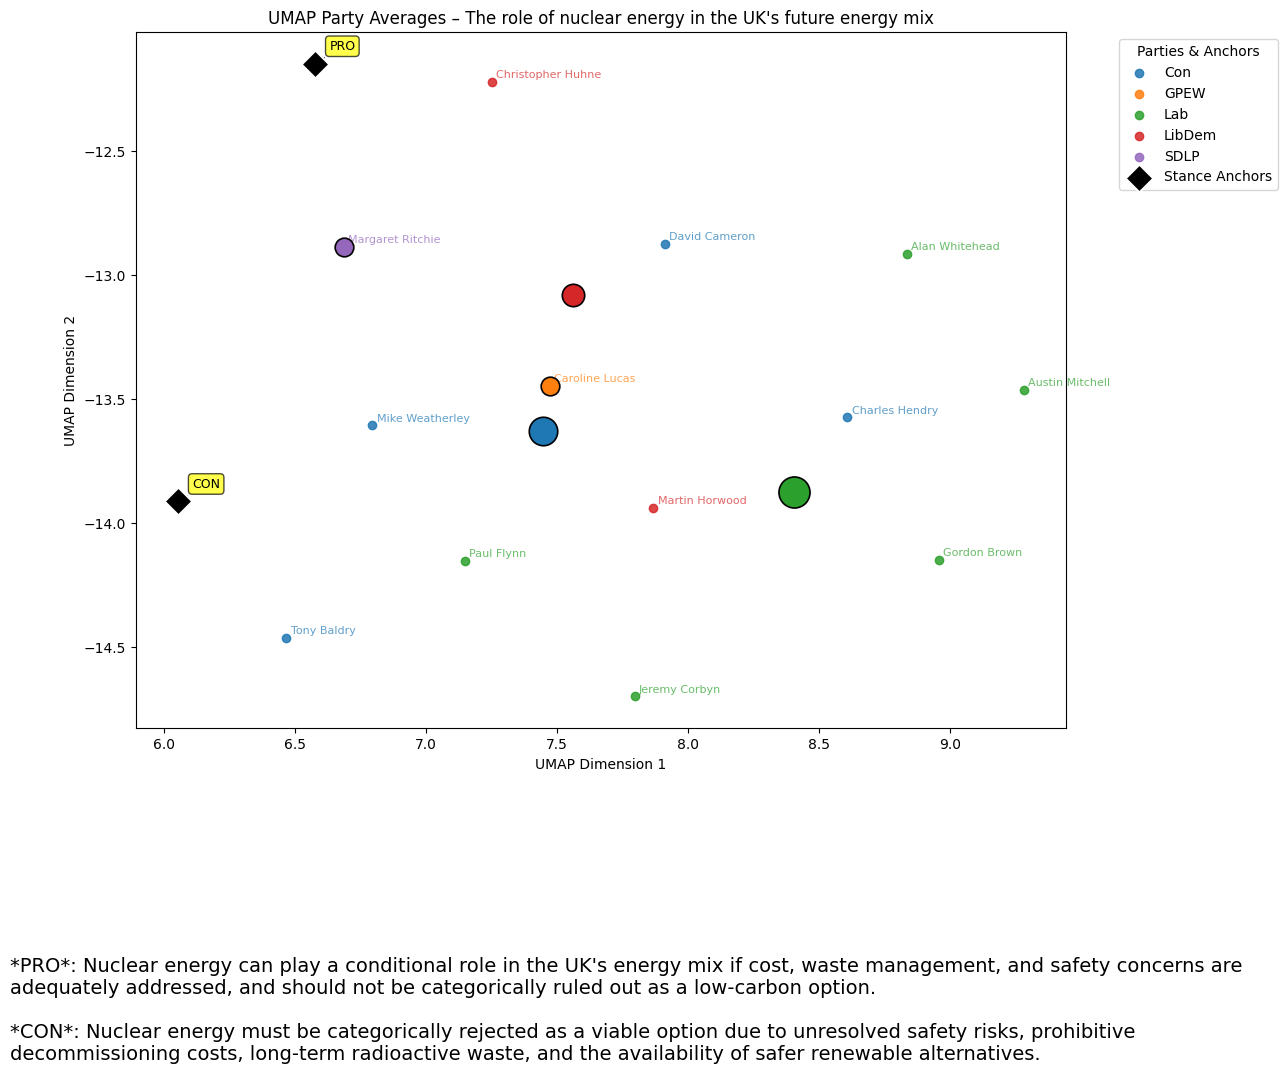

In [ ]:
embeddings = uk.compute_umap_embeddings('nuclear', general_anchors)
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [ ]:
# create axis of controversy based on anchor 0 (pro) and anchor 1 (con)
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, general_anchors)

# print cosine similarity between anchor embeddings
print("Cosine similarity between anchor embeddings:")
sim = uk.cosine_similarity(anchor_embeddings[0], anchor_embeddings[1])
print(sim)

issue = general_anchors['topic']
party_df = uk.axis_of_controversy(topic, issue=issue, anchor_embeddings=anchor_embeddings, speaker_embeddings=speaker_embeddings)


# order by controversy score
party_df = party_df.sort_values(by='controversy_score', ascending=True)
party_df

Computing embeddings for topic: nuclear
['The politician opposes the development of nuclear energy due to safety concerns and the lack of relevant infrastructure in the UK.', 'The politician believes nuclear energy should not be pursued due to significant cost overruns, safety concerns highlighted by the Fukushima disaster, and declining public confidence, particularly given other countries’ abandonment of nuclear plans.', 'The politician opposes the use of nuclear energy due to concerns about the significant and unaddressed costs of decommissioning and nuclear waste disposal.', 'The politician believes nuclear energy should be part of the UK’s energy mix, but opposes government funding and recognises the need to maintain reliable power generation.', 'The politician opposes the development of new nuclear power stations due to concerns about safety, cost, waste disposal, and lack of international standards.', 'The politician opposes nuclear energy due to concerns about its safety, cost,

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.92s/it]

Cosine similarity between anchor embeddings:
0.6551593


,party,controversy_score,issue
1,GPEW,-0.178596,The role of nuclear energy in the UK's future ...
0,Con,-0.137910,The role of nuclear energy in the UK's future ...
4,SDLP,-0.127981,The role of nuclear energy in the UK's future ...
2,Lab,-0.105351,The role of nuclear energy in the UK's future ...
3,LibDem,-0.023580,The role of nuclear energy in the UK's future ...


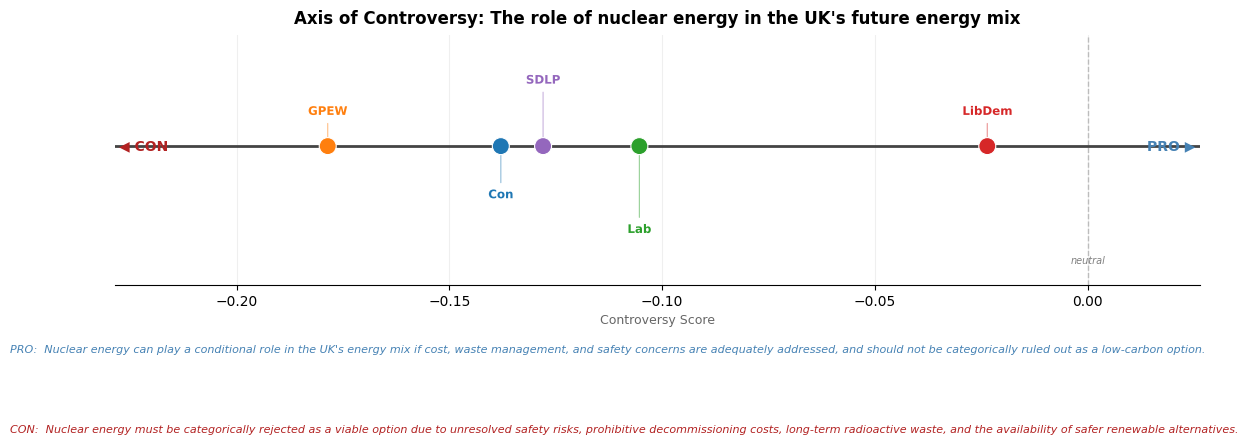

In [ ]:
# plot axis of controversy with parties projected onto it
uk.plot_axis_of_controversy(party_df, issue=issue, anchors=general_anchors)

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


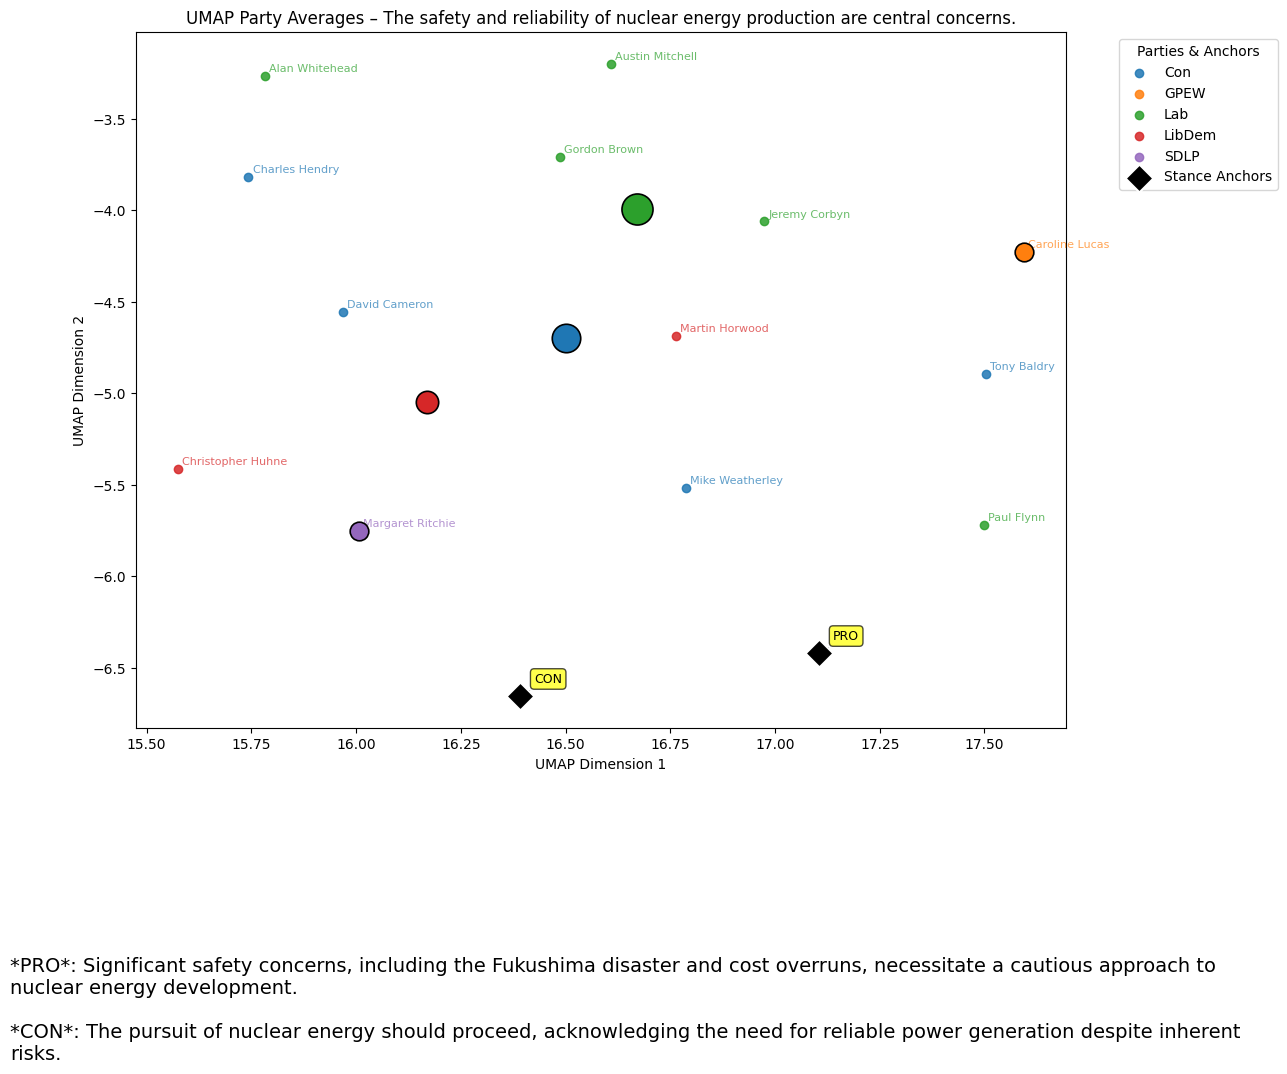

In [ ]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[0])
uk.plot_umap_party_averages(embeddings, 'nuclear')

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.38s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


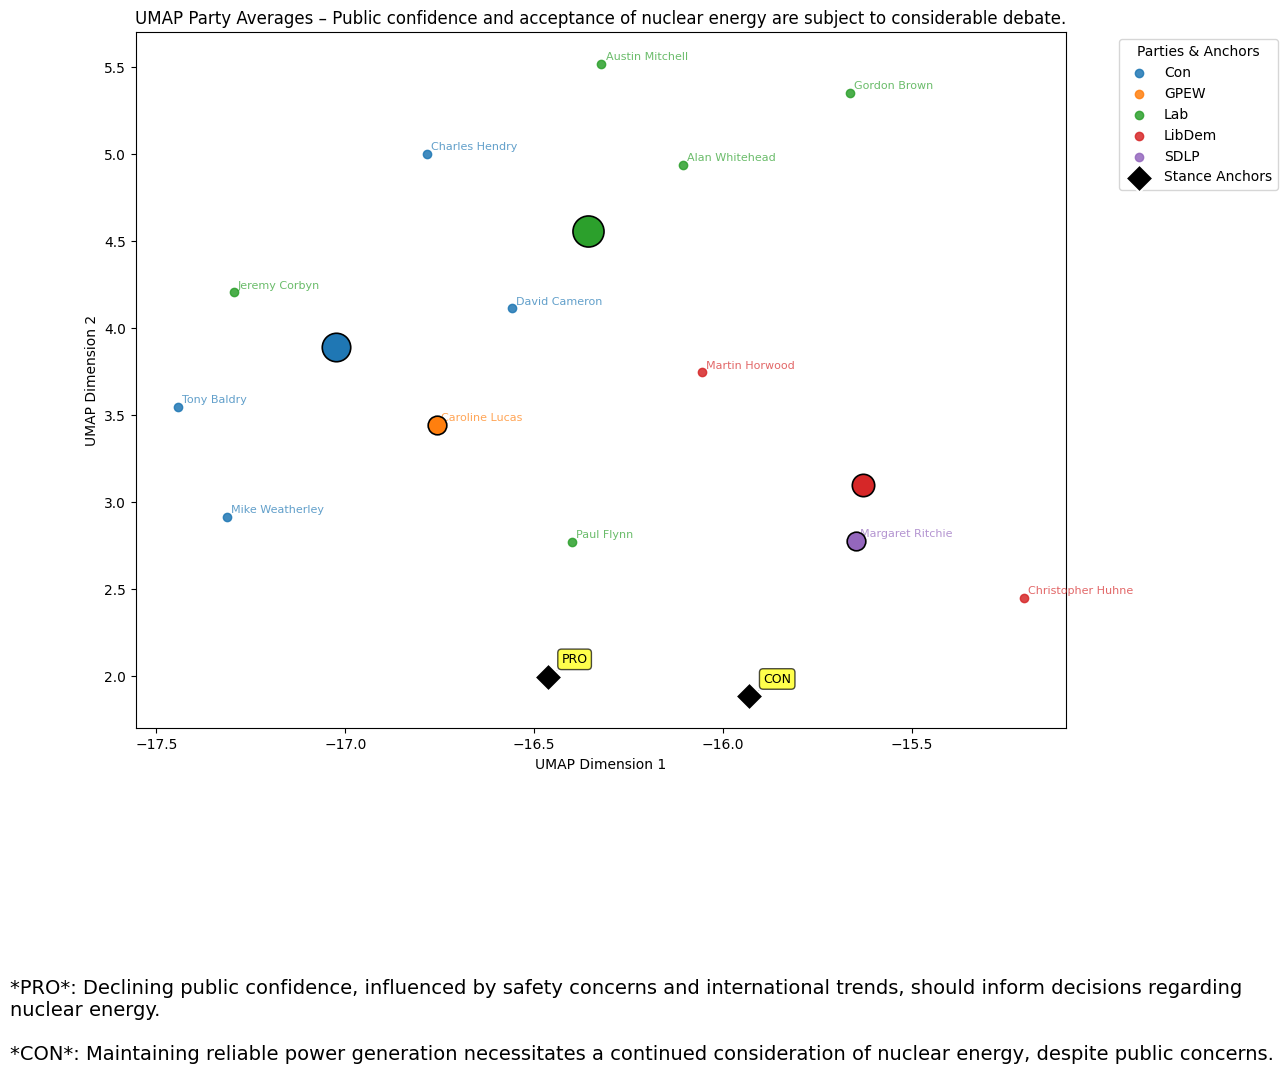

In [ ]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[2])
uk.plot_umap_party_averages(embeddings, 'nuclear')

## References
[1] Sylvester, C. (Creator), Greene, Z. (Creator), Ershova, A. (Contributor), Khokhlova, A. (Contributor), Yordanova, N. (Creator) (21 Feb 2023). ParlEE plenary speeches V2 data set: Annotated full-text of 15.1 million sentence-level plenary speeches of six EU legislative chambers. Harvard Dataverse. 10.7910/DVN/VOPK0E

[2] Kato, Ken & Cochrane, Christopher. (2025). KOKKAI DOC: An LLM-driven framework for scaling parliamentary representatives. 10.48550/arXiv.2505.07118. 